# Notebook 3: Spectral Classification
This notebook aims to leverage the information acquired from the second notebook to build a spectral, pixel classifier so that we try to answer:

> How well does spectral information classify grains as bands are reduced?

## 0. Imports

In [59]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk

import warnings
warnings.filterwarnings('ignore')

from hsi_utils import load_data, load_cube, build_foreground_mask_auto

from scipy.signal import find_peaks

from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.pipeline import make_pipeline

import math

from collections import Counter

import re, os

## 1. Load Data

In [60]:
from pathlib import Path

train_files, valid_files, test_files, files_split = load_data(
    mode="direct",
    dataset_path=Path(
        "/mnt/c/Users/isaac/HSI_Dataset"
    ),
    varieties=("barley", "corn", "flax")
)

[OK] Found dataset: /mnt/c/Users/isaac/HSI_Dataset
[OK] Detected flat dataset layout: HDF5 files are directly inside the dataset folder
Sample files:
   barley_l0.hdf5
   barley_l1.hdf5
   barley_l2.hdf5
   barley_l3.hdf5
   barley_l4.hdf5
   barley_m0.hdf5
   barley_m1.hdf5
   barley_m2.hdf5
   barley_m3.hdf5
   barley_m4.hdf5
ROOT:     /mnt/c/Users/isaac/HSI_Dataset
Basepath: /mnt/c/Users/isaac/HSI_Dataset
OUTDIR:   /mnt/c/Users/isaac/HSI_Dataset/processed/quickrun
Total .hdf5 files found: 45
Valid HDF5 files: 45
Invalid/unreadable files: 0


In [61]:
# --- Load cached grain spectra with image-level split ---
CACHE_PATH = "cached_pixels.npz"

data = np.load(CACHE_PATH, allow_pickle=True)

X_all_raw = data["X_all_raw"]
y_all = data["y_all"]
image_id_all = data["image_id_all"]
split_all = data["split_all"]
size_all = data["size_all"]
wlens = data["wlens"]
varieties = list(data["varieties"])

wavelengths = wlens

print("X_all_raw shape:", X_all_raw.shape)
print("y_all shape:", y_all.shape)
print("Loaded varieties:", varieties)

print("\nPixels per split:")
print(pd.Series(split_all).value_counts())

print("\nImages per split:")
print(pd.DataFrame({
    "image": image_id_all,
    "split": split_all
}).drop_duplicates().groupby("split").size())

X_all_raw shape: (45000, 224)
y_all shape: (45000,)
Loaded varieties: ['barley', 'corn', 'flax']

Pixels per split:
train    27000
valid     9000
test      9000
Name: count, dtype: int64

Images per split:
split
test      9
train    27
valid     9
dtype: int64


In [62]:
# --- Load band-selection results from spectral exploration ---
selected_band_indices_pca = np.load("selected_band_indices_pca.npy") 
selected_band_indices_vip = np.load("selected_band_indices_vip.npy") 

selected_1_band_indices_pca = np.load("selected_1_band_indices_pca.npy") 
selected_2_band_indices_pca = np.load("selected_2_band_indices_pca.npy") 
selected_3_band_indices_pca = np.load("selected_3_band_indices_pca.npy")
selected_4_band_indices_pca = np.load("selected_4_band_indices_pca.npy") 
selected_5_band_indices_pca = np.load("selected_5_band_indices_pca.npy") 
selected_6_band_indices_pca = np.load("selected_6_band_indices_pca.npy") 
selected_7_band_indices_pca = np.load("selected_7_band_indices_pca.npy") 
selected_8_band_indices_pca = np.load("selected_8_band_indices_pca.npy")
selected_9_band_indices_pca = np.load("selected_9_band_indices_pca.npy") 
selected_10_band_indices_pca = np.load("selected_10_band_indices_pca.npy") 

selected_1_band_indices_vip = np.load("selected_1_band_indices_vip.npy") 
selected_2_band_indices_vip = np.load("selected_2_band_indices_vip.npy") 
selected_3_band_indices_vip = np.load("selected_3_band_indices_vip.npy") 
selected_4_band_indices_vip = np.load("selected_4_band_indices_vip.npy") 
selected_5_band_indices_vip = np.load("selected_5_band_indices_vip.npy") 
selected_6_band_indices_vip = np.load("selected_6_band_indices_vip.npy") 
selected_7_band_indices_vip = np.load("selected_7_band_indices_vip.npy") 
selected_8_band_indices_vip = np.load("selected_8_band_indices_vip.npy") 
selected_9_band_indices_vip = np.load("selected_9_band_indices_vip.npy") 
selected_10_band_indices_vip = np.load("selected_10_band_indices_vip.npy") 

rgb_band_indices = np.load("rgb_band_indices.npy") 
usable_band_indices = np.load("usable_band_indices.npy")

saved_wavelengths = np.load("wavelengths.npy")
vip_scores = np.load("vip_scores.npy")

wavelengths = np.asarray(wlens, dtype=float)

if not np.allclose(wavelengths, saved_wavelengths): raise ValueError("The cached classification wavelengths do not match the band-selection wavelengths")

print("Number of usable bands:", len(usable_band_indices))
print("Range of bands used (in nm):", np.round(wavelengths[[usable_band_indices[0], usable_band_indices[-1]]], 1))

print("PCA 1:", np.round(wavelengths[selected_1_band_indices_pca], 1)) 
print("PCA 3:", np.round(wavelengths[selected_3_band_indices_pca], 1)) 
print("VIP 1:", np.round(wavelengths[selected_1_band_indices_vip], 1)) 
print("VIP 3:", np.round(wavelengths[selected_3_band_indices_vip], 1)) 
print("RGB proxy:", np.round(wavelengths[rgb_band_indices], 1))

Number of usable bands: 199
Range of bands used (in nm): [432.  968.5]
PCA 1: [491.9]
PCA 3: [491.9 611.9 641.6]
VIP 1: [505.1]
VIP 3: [505.1 915.8 585. ]
RGB proxy: [649.8 528.9 450.1]


## 2. PLS-DA — component selection via cross-validation

In [63]:
# --- Encode labels for multi-class PLS-DA ---
lb = LabelBinarizer()

Y_all = lb.fit_transform(y_all)

print("Classes:", lb.classes_)
print("Y_all shape:", Y_all.shape)

Classes: ['barley' 'corn' 'flax']
Y_all shape: (45000, 3)


In [64]:
N_PLSDA = 3   # chosen where curve transitions from meaningful gains to marginal improvement

In [65]:
# --- Image-level train/valid/test split for PLS-DA ---

lb = LabelBinarizer()
Y_all = lb.fit_transform(y_all)

train_mask = split_all == "train"
valid_mask = split_all == "valid"
test_mask  = split_all == "test"

X_train = X_all_raw[train_mask]
Y_train = Y_all[train_mask]
y_train = y_all[train_mask]

X_valid = X_all_raw[valid_mask]
Y_valid = Y_all[valid_mask]
y_valid = y_all[valid_mask]

X_test = X_all_raw[test_mask]
Y_test = Y_all[test_mask]
y_test = y_all[test_mask]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test:", X_test.shape)

print("\nUnique train images:", len(np.unique(image_id_all[train_mask])))
print("Unique valid images:", len(np.unique(image_id_all[valid_mask])))
print("Unique test images:", len(np.unique(image_id_all[test_mask])))

Train: (27000, 224)
Valid: (9000, 224)
Test: (9000, 224)

Unique train images: 27
Unique valid images: 9
Unique test images: 9


Best number of PLS components: 20
Best validation accuracy: 0.9863333333333333


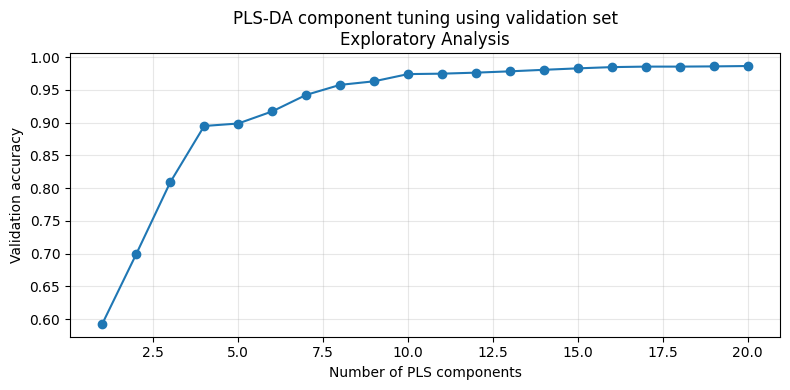

In [66]:
# --- Tune PLS-DA components using validation set ---
component_range = range(1, 21)
valid_scores = []

# Compute training-set mean only
train_mean = X_train.mean(axis=0)

# Apply same centering to train and validation
X_train_mc = X_train - train_mean
X_valid_mc = X_valid - train_mean

for n_comp in component_range:

    model = PLSRegression(n_components=n_comp, max_iter=500)

    model.fit(X_train_mc, Y_train)

    Y_valid_scores = model.predict(X_valid_mc)
    y_valid_pred = lb.classes_[np.argmax(Y_valid_scores, axis=1)]

    acc = accuracy_score(y_valid, y_valid_pred)
    valid_scores.append(acc)

best_n = component_range[np.argmax(valid_scores)]

print("Best number of PLS components:", best_n)
print("Best validation accuracy:", max(valid_scores))

plt.figure(figsize=(8, 4))
plt.plot(component_range, valid_scores, marker="o")
plt.xlabel("Number of PLS components")
plt.ylabel("Validation accuracy")
plt.title("PLS-DA component tuning using validation set\nExploratory Analysis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Number of PLS-DA components tuned using the validation set. 
* For each candidate number of components, the model is fitted only on the training set and evaluated on the validation set. The component number with the highest validation accuracy is selected, preventing the test set from influencing model selection and keeping the final test evaluation unbiased.

## 2. Final PLS-DA model - evaluation

In [67]:
# --- Compare PLS-DA using all bands vs PCA-selected bands ---
def evaluate_plsda_band_subset(
    X_train, Y_train, y_train,
    X_valid, Y_valid, y_valid,
    X_test, Y_test, y_test,
    band_indices,
    label
):
    """
    Train and evaluate multi-class PLS-DA using selected wavelength bands
    Mean centering is fitted on train set only and then applied to validation and test sets
    """

    X_train_sub = X_train[:, band_indices]
    X_valid_sub = X_valid[:, band_indices]
    X_test_sub  = X_test[:, band_indices]

    # Training-set mean only
    train_mean = X_train_sub.mean(axis=0)

    X_train_mc = X_train_sub - train_mean
    X_valid_mc = X_valid_sub - train_mean
    X_test_mc  = X_test_sub  - train_mean

    max_components = min(15, X_train_mc.shape[1], X_train_mc.shape[0] - 1)

    best_acc = -1
    best_n = None
    best_model = None

    for n_comp in range(1, max_components + 1):

        model = PLSRegression(
            n_components=n_comp,
            scale=False,
            max_iter=1000,
            tol=1e-6
        )
        
        model.fit(X_train_mc, Y_train)

        Y_valid_scores = model.predict(X_valid_mc)
        y_valid_pred = lb.classes_[np.argmax(Y_valid_scores, axis=1)]

        acc = accuracy_score(y_valid, y_valid_pred)

        if acc > best_acc:
            best_acc = acc
            best_n = n_comp
            best_model = model

    Y_test_scores = best_model.predict(X_test_mc)
    y_test_pred = lb.classes_[np.argmax(Y_test_scores, axis=1)]

    test_acc = accuracy_score(y_test, y_test_pred)

    return {
        "label": label,
        "n_bands": len(band_indices),
        "band_indices": band_indices,
        "wavelengths": wavelengths[band_indices],
        "best_n_components": best_n,
        "val_accuracy": best_acc,
        "test_accuracy": test_acc,
        "test_precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=lb.classes_),
        "y_test_pred": y_test_pred,
        "model": best_model,
        "train_mean": train_mean
    }

In [68]:
# --- PLS-DA comparison using usable, RGB and selected subsets ---

results_plsda_bands = []

# "All bands" now means the full usable 430–970 nm spectrum.
all_band_indices = usable_band_indices

band_cases = [
    ("PLS-DA: all bands", all_band_indices),

    ("PLS-DA: top 100 PCA bands", selected_band_indices_pca[:100]), 
    ("PLS-DA: top 100 VIP bands", selected_band_indices_vip[:100]),
    ("PLS-DA: top 80 PCA bands", selected_band_indices_pca[:80]), 
    ("PLS-DA: top 80 VIP bands", selected_band_indices_vip[:80]), 
    ("PLS-DA: top 50 PCA bands", selected_band_indices_pca[:50]), 
    ("PLS-DA: top 50 VIP bands", selected_band_indices_vip[:50]), 
    ("PLS-DA: top 30 PCA bands", selected_band_indices_pca[:30]), 
    ("PLS-DA: top 30 VIP bands", selected_band_indices_vip[:30]), 
    ("PLS-DA: top 20 PCA bands", selected_band_indices_pca[:20]), 
    ("PLS-DA: top 20 VIP bands", selected_band_indices_vip[:20]), 

    # The 1–10 band models use nested, peak-separated subsets
    ("PLS-DA: top 10 PCA bands", selected_10_band_indices_pca), 
    ("PLS-DA: top 10 VIP bands", selected_10_band_indices_vip), 
    ("PLS-DA: top 9 PCA bands", selected_9_band_indices_pca), 
    ("PLS-DA: top 9 VIP bands", selected_9_band_indices_vip), 
    ("PLS-DA: top 8 PCA bands", selected_8_band_indices_pca), 
    ("PLS-DA: top 8 VIP bands", selected_8_band_indices_vip),
    ("PLS-DA: top 7 PCA bands", selected_7_band_indices_pca), 
    ("PLS-DA: top 7 VIP bands", selected_7_band_indices_vip), 
    ("PLS-DA: top 6 PCA bands", selected_6_band_indices_pca), 
    ("PLS-DA: top 6 VIP bands", selected_6_band_indices_vip), 
    ("PLS-DA: top 5 PCA bands", selected_5_band_indices_pca), 
    ("PLS-DA: top 5 VIP bands", selected_5_band_indices_vip), 
    ("PLS-DA: top 4 PCA bands", selected_4_band_indices_pca), 
    ("PLS-DA: top 4 VIP bands", selected_4_band_indices_vip), 

    ("PLS-DA: RGB proxy bands", rgb_band_indices),
   
    ("PLS-DA: top 3 PCA bands", selected_3_band_indices_pca), 
    ("PLS-DA: top 3 VIP bands", selected_3_band_indices_vip), 
    ("PLS-DA: top 2 PCA bands", selected_2_band_indices_pca), 
    ("PLS-DA: top 2 VIP bands", selected_2_band_indices_vip), 
    ("PLS-DA: top 1 PCA band", selected_1_band_indices_pca), 
    ("PLS-DA: top 1 VIP band", selected_1_band_indices_vip),
]

for label, band_indices in band_cases:

    result = evaluate_plsda_band_subset(
        X_train, Y_train, y_train,
        X_valid, Y_valid, y_valid,
        X_test, Y_test, y_test,
        band_indices,
        label=label
    )

    results_plsda_bands.append(result)

    print(f"\n--- {label} ---")
    print(f"Number of bands: {result['n_bands']}")

    if result["n_bands"] <= 10:
        print(
            "Wavelengths:",
            np.round(wavelengths[band_indices], 1)
        )


    print(f"Best PLS components: " f"{result['best_n_components']}") 
    print(f"Validation accuracy: " f"{result['val_accuracy']:.4f}") 
    print(f"Test accuracy: " f"{result['test_accuracy']:.4f}")


--- PLS-DA: all bands ---
Number of bands: 199
Best PLS components: 15
Validation accuracy: 0.9867
Test accuracy: 0.9886

--- PLS-DA: top 100 PCA bands ---
Number of bands: 100
Best PLS components: 11
Validation accuracy: 0.9637
Test accuracy: 0.9706

--- PLS-DA: top 100 VIP bands ---
Number of bands: 100
Best PLS components: 15
Validation accuracy: 0.9719
Test accuracy: 0.9758

--- PLS-DA: top 80 PCA bands ---
Number of bands: 80
Best PLS components: 15
Validation accuracy: 0.9554
Test accuracy: 0.9613

--- PLS-DA: top 80 VIP bands ---
Number of bands: 80
Best PLS components: 13
Validation accuracy: 0.9721
Test accuracy: 0.9741

--- PLS-DA: top 50 PCA bands ---
Number of bands: 50
Best PLS components: 12
Validation accuracy: 0.9379
Test accuracy: 0.9434

--- PLS-DA: top 50 VIP bands ---
Number of bands: 50
Best PLS components: 14
Validation accuracy: 0.9628
Test accuracy: 0.9660

--- PLS-DA: top 30 PCA bands ---
Number of bands: 30
Best PLS components: 14
Validation accuracy: 0.8384


With the introduction of explicit **mean centering**, we are:
1) computing the training mean (avg. reflectance at every wavelength across train samples) -> so one mean per wavelength
2) subtracting the training mean (train/valid/test all centered with same reference point) -> we get deviations from mean spectrum

The mean centering is performed using the training set only, so that the reference points we're working with are consistent across all sets. Using all three sets during model fitting would lead to data leakage, whilst independently centering the sets would avoid the data leakage problem, but the problem of different feature spaces would arise. Per-class mean centering is also not utilised as it may remove between-class spectral differences that are useful for discrimination.

This follows the logic of the original PCA notebook, where mean centering during PLS-DA cross-validation is computed inside each training fold and then applied to the corresponding validation fold. 


In [ ]:
# --- Main result table: full spectra + thesis-relevant 1/3-band models ---

main_result_labels = [
    "PLS-DA: all bands",
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]

main_rows = []

for label in main_result_labels:
    r = next(res for res in results_plsda_bands if res["label"] == label)

    main_rows.append({
        "Model": label,
        "Bands": r["n_bands"],
        "Selected wavelengths [nm]": np.round(wavelengths[r["band_indices"]], 1).tolist(),
        "Best components": r["best_n_components"],
        "Validation accuracy": r["val_accuracy"],
        "Test accuracy": r["test_accuracy"],
    })

main_results_df = pd.DataFrame(main_rows)

display(main_results_df)


,Model,Bands,Selected wavelengths [nm],Best components,Validation accuracy,Test accuracy
0,PLS-DA: all bands,199,"[432.0, 434.6, 437.2, 439.8, 442.4, 445.0, 447...",15,0.986667,0.988556
1,PLS-DA: top 1 PCA band,1,[491.9],1,0.522000,0.522000
2,PLS-DA: top 1 VIP band,1,[505.1],1,0.544111,0.540556
3,PLS-DA: top 3 PCA bands,3,"[491.9, 611.9, 641.6]",3,0.813778,0.791778
4,PLS-DA: top 3 VIP bands,3,"[505.1, 915.8, 585.0]",3,0.851333,0.843222


,Model,Method,Number of bands,Best PLS components,Validation accuracy,Test accuracy
0,PLS-DA: all bands,All bands,199,15,0.986667,0.988556
1,PLS-DA: top 1 PCA band,PCA,1,1,0.522000,0.522000
2,PLS-DA: top 2 PCA bands,PCA,2,2,0.805000,0.782444
3,PLS-DA: top 3 PCA bands,PCA,3,3,0.813778,0.791778
4,PLS-DA: top 4 PCA bands,PCA,4,4,0.815667,0.797000
5,PLS-DA: top 5 PCA bands,PCA,5,4,0.861333,0.862778
6,PLS-DA: top 6 PCA bands,PCA,6,6,0.862889,0.862444
7,PLS-DA: top 7 PCA bands,PCA,7,7,0.864333,0.864889
8,PLS-DA: top 8 PCA bands,PCA,8,8,0.907889,0.913333
9,PLS-DA: top 9 PCA bands,PCA,9,7,0.915667,0.919556


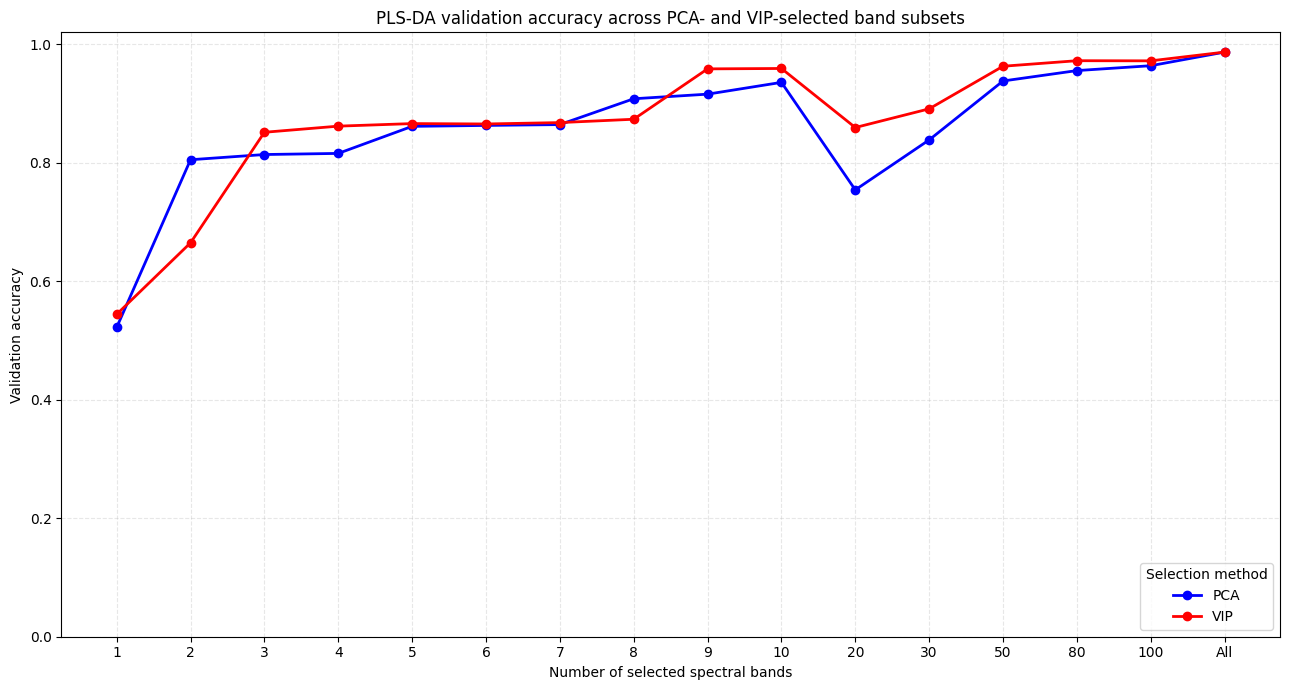

In [ ]:
# --- Validation accuracy across PCA and VIP band subsets ---

# Build a clean metrics table
metrics_df = pd.DataFrame([
    {
        "Model": r["label"],
        "Method": (
            "VIP" if "VIP" in r["label"]
            else "PCA" if "PCA" in r["label"]
            else "RGB" if "RGB" in r["label"]
            else "All bands"
        ),
        "Number of bands": int(r["n_bands"]),
        "Best PLS components": int(r["best_n_components"]),
        "Validation accuracy": r["val_accuracy"],
        "Test accuracy": r["test_accuracy"]
    }
    for r in results_plsda_bands
])


# Retrieve the shared full-spectrum result
all_bands_rows = metrics_df[
    metrics_df["Method"] == "All bands"
].copy()

if all_bands_rows.empty:
    raise ValueError(
        "No full-spectrum result was found in results_plsda_bands."
    )

all_bands_row = all_bands_rows.iloc[0]
n_all_bands = int(all_bands_row["Number of bands"])


# Prepare one ordered dataframe for each selection method
method_dfs = {}

for method in ["PCA", "VIP"]:

    method_df = metrics_df[
        metrics_df["Method"] == method
    ].copy()

    # Add the full-spectrum result to both plots
    full_spectrum_reference = all_bands_row.copy()
    full_spectrum_reference["Method"] = method
    full_spectrum_reference["Model"] = (
        f"PLS-DA: all bands ({method} reference)"
    )

    method_df = pd.concat(
        [
            method_df,
            full_spectrum_reference.to_frame().T
        ],
        ignore_index=True
    )

    numeric_columns = [
        "Number of bands",
        "Best PLS components",
        "Validation accuracy",
        "Test accuracy"
    ]

    method_df[numeric_columns] = method_df[
        numeric_columns
    ].apply(pd.to_numeric)

    method_df = (
        method_df
        .drop_duplicates(
            subset=["Number of bands"],
            keep="first"
        )
        .sort_values("Number of bands")
        .reset_index(drop=True)
    )

    method_dfs[method] = method_df


# Display the underlying results once
display(
    metrics_df.sort_values(
        ["Method", "Number of bands"]
    ).reset_index(drop=True)
)


# Shared x-axis ordering
band_order = (
    pd.concat([
        method_dfs["PCA"]["Number of bands"],
        method_dfs["VIP"]["Number of bands"]
    ])
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# Place the all-band case last
if n_all_bands in band_order:
    band_order.remove(n_all_bands)
    band_order.append(n_all_bands)

x_positions = np.arange(len(band_order))

x_labels = [
    "All"
    if int(n_bands) == n_all_bands
    else str(int(n_bands))
    for n_bands in band_order
]

method_colours = {
    "PCA": "blue",
    "VIP": "red"
}


# Plot validation accuracy
fig, ax = plt.subplots(figsize=(13, 7))

for method in ["PCA", "VIP"]:

    plot_df = (
        method_dfs[method]
        .set_index("Number of bands")
        .reindex(band_order)
    )

    ax.plot(
        x_positions,
        plot_df["Validation accuracy"],
        color=method_colours[method],
        linestyle="-",
        marker="o",
        linewidth=2,
        markersize=6,
        label=method
    )

ax.set_xticks(
    x_positions,
    x_labels
)

ax.set_xlabel("Number of selected spectral bands")
ax.set_ylabel("Validation accuracy")

ax.set_title(
    "PLS-DA validation accuracy across "
    "PCA- and VIP-selected band subsets"
)

ax.set_ylim(0, 1.02)

ax.grid(
    True,
    alpha=0.3,
    linestyle="--"
)

ax.legend(
    title="Selection method",
    loc="lower right"
)

plt.tight_layout()
plt.show()

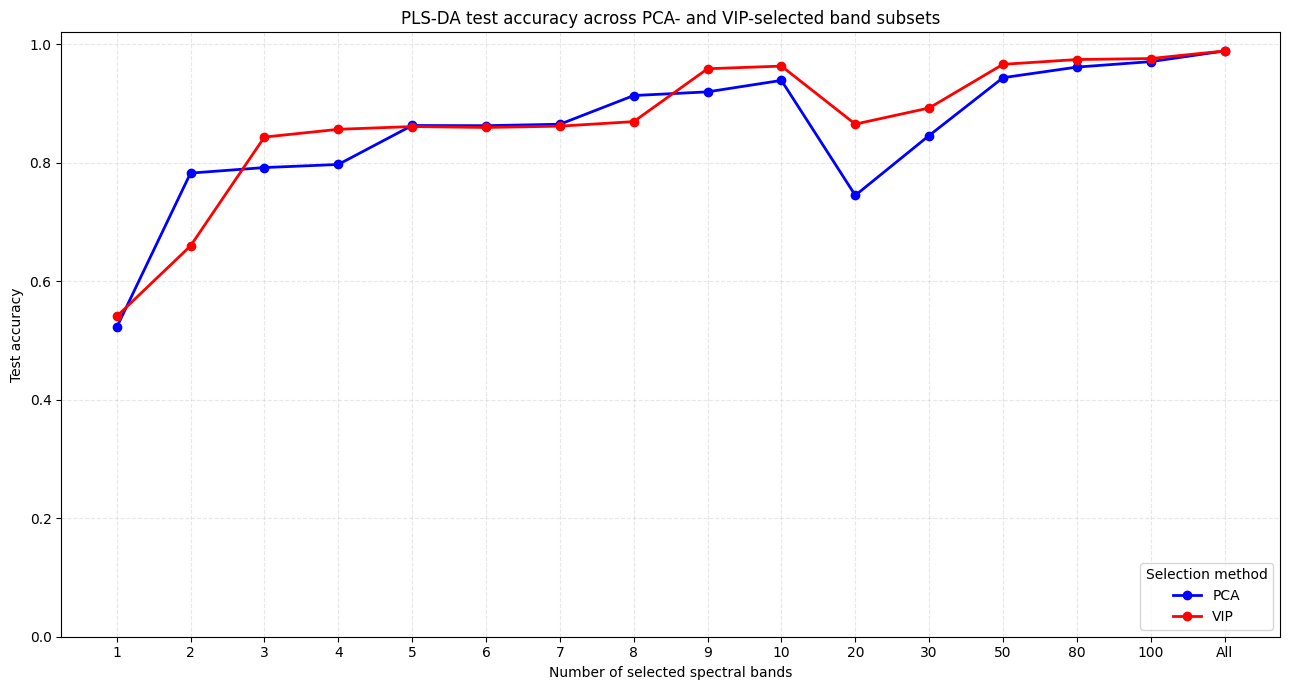

In [74]:
# --- Test accuracy across PCA and VIP band subsets ---

fig, ax = plt.subplots(figsize=(13, 7))

for method in ["PCA", "VIP"]:

    plot_df = (
        method_dfs[method]
        .set_index("Number of bands")
        .reindex(band_order)
    )

    ax.plot(
        x_positions,
        plot_df["Test accuracy"],
        color=method_colours[method],
        linestyle="-",
        marker="o",
        linewidth=2,
        markersize=6,
        label=method
    )

ax.set_xticks(
    x_positions,
    x_labels
)

ax.set_xlabel("Number of selected spectral bands")
ax.set_ylabel("Test accuracy")

ax.set_title(
    "PLS-DA test accuracy across "
    "PCA- and VIP-selected band subsets"
)

ax.set_ylim(0, 1.02)

ax.grid(
    True,
    alpha=0.3,
    linestyle="--"
)

ax.legend(
    title="Selection method",
    loc="lower right"
)

plt.tight_layout()
plt.show()

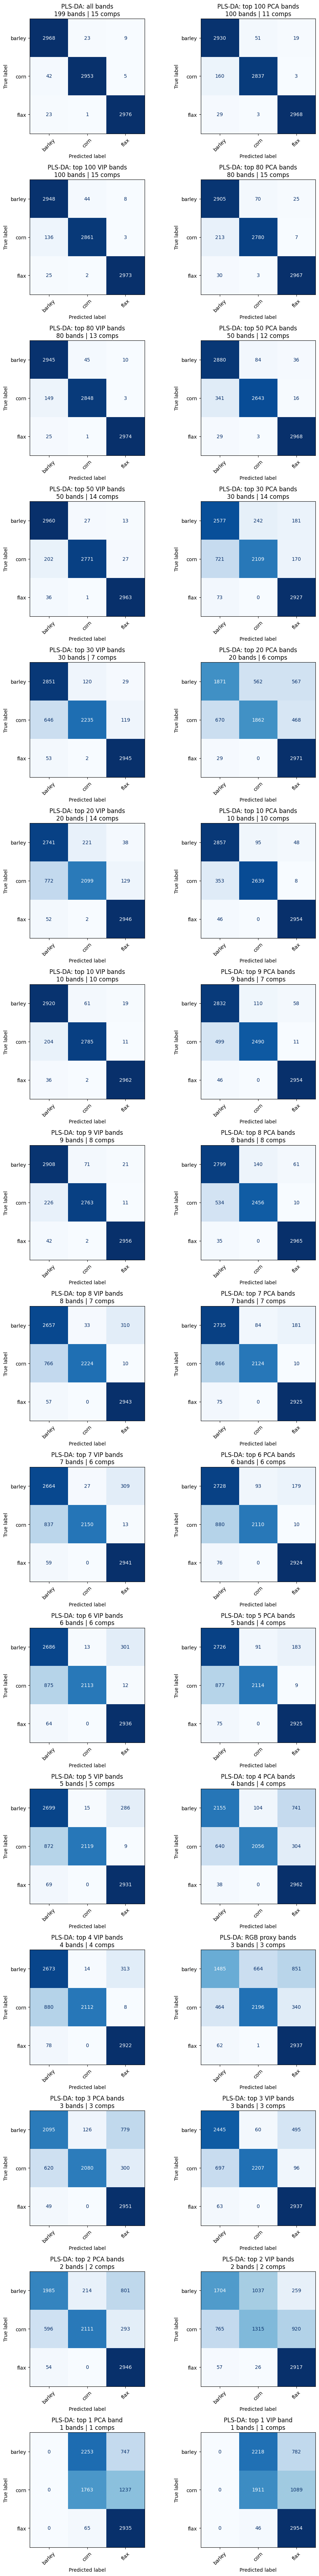

In [71]:
# --- Plot confusion matrices side by side ---
n_models = len(results_plsda_bands)
max_per_row = 2

n_rows = math.ceil(n_models / max_per_row)
n_cols = min(max_per_row, n_models)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows)
)

if n_rows == 1 and n_cols == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for ax, result in zip(axes, results_plsda_bands):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=lb.classes_
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"{result['label']}\n"
        f"{result['n_bands']} bands | {result['best_n_components']} comps"
    )

    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(results_plsda_bands):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

It seems that the best combination of retaining the least bands possible, whilst still obtaining reliable classification performance is going with the top 20 bands. This represents just a sixth of the full set, yet as the line graph and confusion matrices above show, still achieves respectable performance. Accuracy, precision, recall and F1 score all hover around 74%, whilst the correctly predicted cases still very much outweigh the other cases in the confusion matrix.

## Image-level majority vote Confusion Matrices

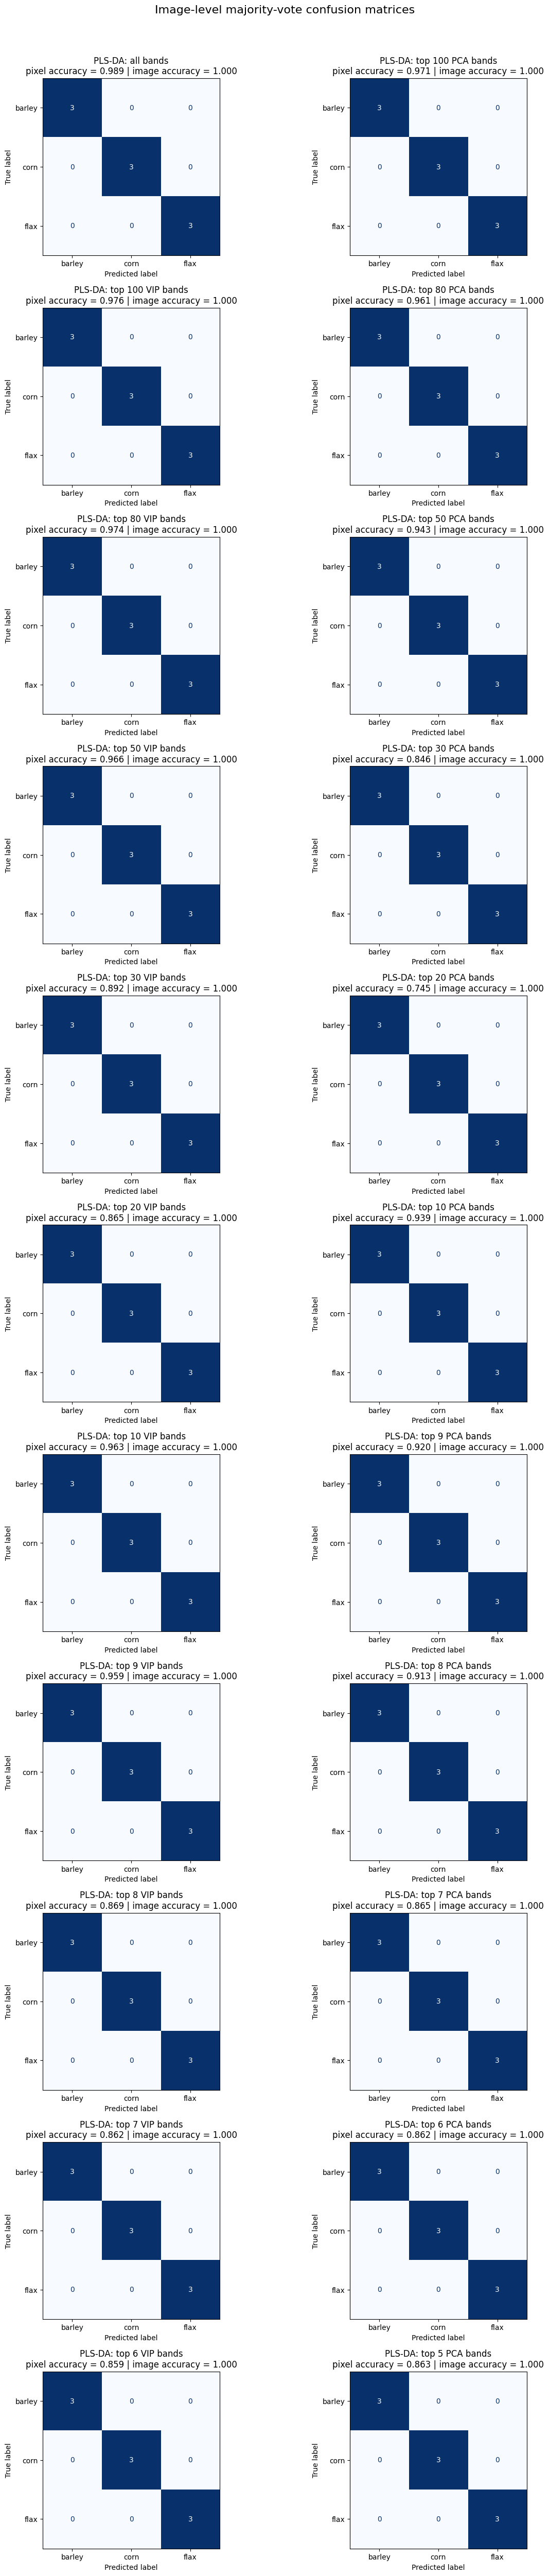

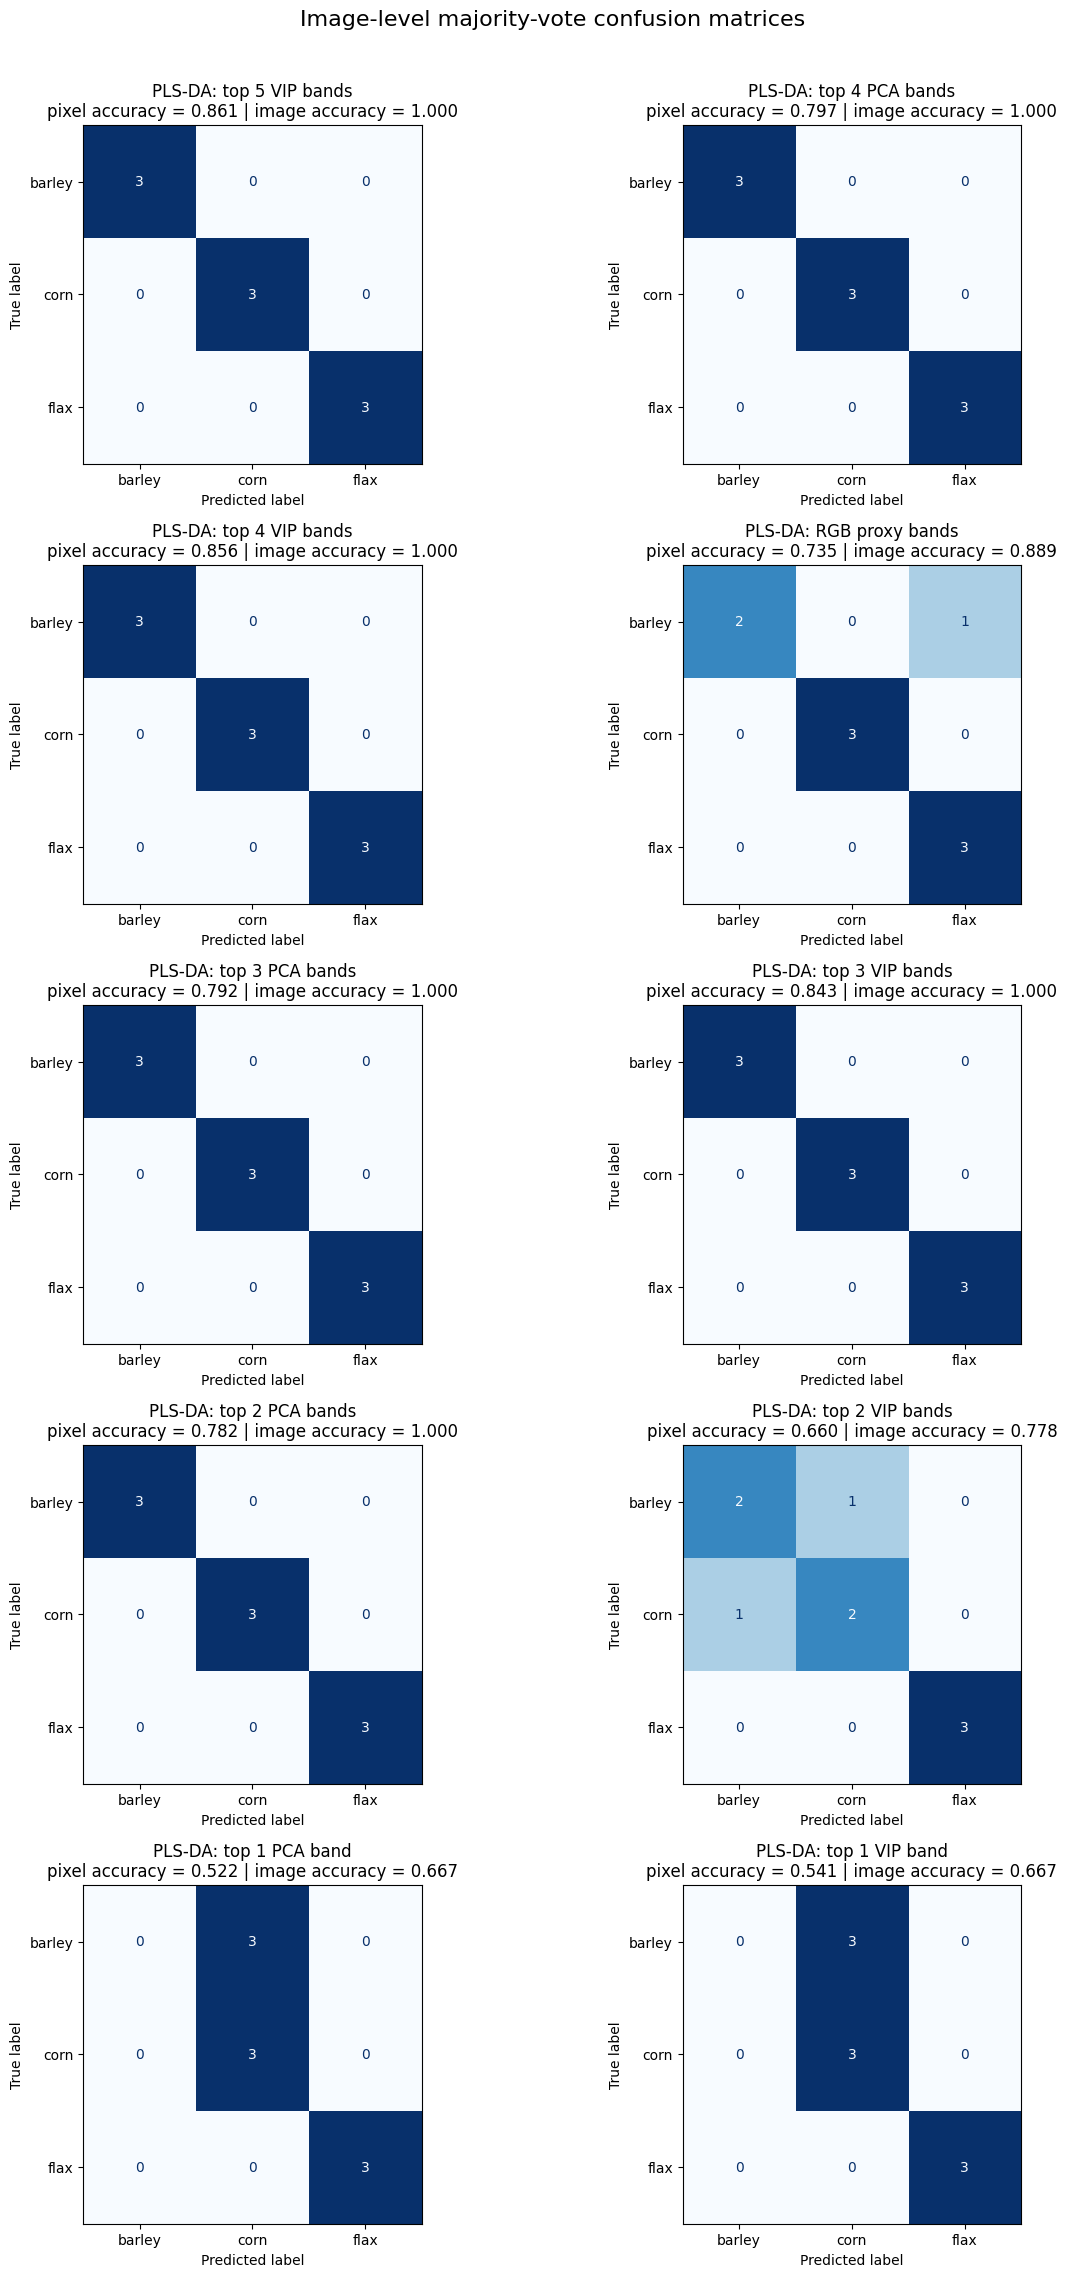

In [72]:
# These retain the same ordering as X_test, y_test and each result["y_test_pred"] array
test_image_ids = np.asarray(
    image_id_all[test_mask]
)

test_sizes = np.asarray(
    size_all[test_mask]
)


# Basic consistency checks
if len(test_image_ids) != len(y_test): raise ValueError( "test_image_ids and y_test have different lengths." )
if len(test_sizes) != len(y_test): raise ValueError( "test_sizes and y_test have different lengths." )

image_level_rows = []

# Convert each model's pixel predictions into image predictions
for result in results_plsda_bands:

    result_label = result["label"]

    y_pred_pixels = np.asarray(result["y_test_pred"])

    if len(y_pred_pixels) != len(y_test): raise ValueError( f"Prediction length mismatch for {result_label}." )

    y_true_images = []
    y_pred_images = []

    # Preserve the image order occurring in the test set.
    unique_test_images = pd.unique(
        test_image_ids
    )

    for image_id in unique_test_images:
        image_mask = ( test_image_ids == image_id )

        image_true_labels = np.unique( y_test[image_mask] )

        image_sizes = np.unique( test_sizes[image_mask] )

        if len(image_true_labels) != 1: raise ValueError( f"Image {image_id} contains multiple true labels." )
        if len(image_sizes) != 1: raise ValueError( f"Image {image_id} contains multiple size labels." )

        true_label = image_true_labels[0]
        image_size = image_sizes[0]

        image_pixel_predictions = (
            y_pred_pixels[image_mask]
        )

        # Count the number of pixel votes for each class.
        vote_counts = np.array([
            np.sum( image_pixel_predictions == class_label )
            for class_label in lb.classes_
        ])

        maximum_votes = vote_counts.max()
        tied_class_indices = np.flatnonzero( vote_counts == maximum_votes )

        vote_tie = ( len(tied_class_indices) > 1 )

        if not vote_tie:

            winning_class_index = int( tied_class_indices[0] )

        else:
            # A tie is unlikely, but resolve it using the mean
            # PLS score among only the tied classes.
            band_indices = result[ "band_indices" ]

            X_image = X_test[
                image_mask
            ][
                :, band_indices
            ]

            X_image_mc = (
                X_image
                - result["train_mean"]
            )

            mean_image_scores = (
                result["model"]
                .predict(X_image_mc)
                .mean(axis=0)
            )

            winning_class_index = int(
                tied_class_indices[
                    np.argmax(
                        mean_image_scores[
                            tied_class_indices
                        ]
                    )
                ]
            )

        majority_prediction = (
            lb.classes_[
                winning_class_index
            ]
        )

        pixel_accuracy_within_image = (
            image_pixel_predictions
            == true_label
        ).mean()

        y_true_images.append(
            true_label
        )

        y_pred_images.append(
            majority_prediction
        )

        image_row = {
            "Model": result_label,
            "Number of bands": result["n_bands"],
            "Image ID": image_id,
            "Size": image_size,
            "True label": true_label,
            "Majority prediction": majority_prediction,
            "Image correct": (
                majority_prediction
                == true_label
            ),
            "Pixel accuracy within image": (
                pixel_accuracy_within_image
            ),
            "Number of sampled pixels": int(
                image_mask.sum()
            ),
            "Vote tie": vote_tie
        }

        # Save each class's vote count and percentage.
        for class_index, class_label in enumerate(
            lb.classes_
        ):

            image_row[
                f"{class_label} votes"
            ] = int(
                vote_counts[class_index]
            )

            image_row[
                f"{class_label} vote proportion"
            ] = (
                vote_counts[class_index]
                / image_mask.sum()
            )

        image_level_rows.append(
            image_row
        )


    y_true_images = np.asarray( y_true_images )

    y_pred_images = np.asarray( y_pred_images )

    image_cm = confusion_matrix(
        y_true_images,
        y_pred_images,
        labels=lb.classes_
    )

    # Add the image-level results to the existing result dictionary.
    result["image_accuracy"] = accuracy_score(
        y_true_images,
        y_pred_images
    )

    result[
        "image_balanced_accuracy"
    ] = balanced_accuracy_score(
        y_true_images,
        y_pred_images
    )

    result[
        "image_f1_macro"
    ] = f1_score(
        y_true_images,
        y_pred_images,
        average="macro",
        zero_division=0
    )

    result[ "image_confusion_matrix" ] = image_cm
    result[ "y_test_image" ] = y_true_images
    result[ "y_pred_image" ] = y_pred_images


# Per-image results
image_level_df = pd.DataFrame( image_level_rows )

# Image-level confusion matrices for every prior model
MATRICES_PER_FIGURE = 22
N_COLUMNS = 2

for figure_start in range(
    0,
    len(results_plsda_bands),
    MATRICES_PER_FIGURE
):

    figure_results = results_plsda_bands[
        figure_start:
        figure_start + MATRICES_PER_FIGURE
    ]

    n_rows = int(
        np.ceil(
            len(figure_results)
            / N_COLUMNS
        )
    )

    fig, axes = plt.subplots(
        n_rows,
        N_COLUMNS,
        figsize=(
            13,
            4.5 * n_rows
        )
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, result in zip(
        axes,
        figure_results
    ):

        display_cm = ConfusionMatrixDisplay(
            confusion_matrix=result[
                "image_confusion_matrix"
            ],
            display_labels=lb.classes_
        )

        display_cm.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format="d"
        )

        ax.set_title(
            f"{result['label']}\n"
            f"pixel accuracy = "
            f"{result['test_accuracy']:.3f} | "
            f"image accuracy = "
            f"{result['image_accuracy']:.3f}"
        )

    for ax in axes[
        len(figure_results):
    ]:
        ax.axis("off")

    fig.suptitle(
        "Image-level majority-vote confusion matrices",
        fontsize=16,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

## Visualizing Results as overplay plots

In [19]:
# --- Incorrect/correct pixel overlay + Classes overlay ---
labels_to_plot = [
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]

class_colours = {
    "barley": [0.121, 0.466, 0.705, 0.45],
    "corn":   [1.000, 0.498, 0.054, 0.45],
    "flax":   [0.172, 0.627, 0.172, 0.45],
}

correct_colour = [0, 1, 0, 0.35]
wrong_colour   = [1, 0, 0, 0.35]


def normalise_for_display(img, mask):
    vals = img[mask]
    lo, hi = np.percentile(vals, [2, 98])
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)


def make_overlay_filename(result_label, class_label):
    label = result_label.lower()
    n_bands = re.search(r"top\s*(\d+)", label).group(1)

    if "pca" in label:
        method = "pca"
    elif "vip" in label:
        method = "vip"
    else:
        method = "unknown"

    return f"top{n_bands}_{method}_{class_label}.png"


test_image_rows = files_split[files_split["split"] == "test"].copy()
test_image_rows = test_image_rows.sort_values(["variety", "size", "rep"]).reset_index(drop=True)

for result_label in labels_to_plot:

    result_to_plot = next(
        r for r in results_plsda_bands
        if r["label"] == result_label
    )

    model = result_to_plot["model"]
    band_indices = result_to_plot["band_indices"]
    train_mean = result_to_plot["train_mean"]

    print("\n" + "=" * 90)
    print("Visualising:", result_label)
    print("Bands:", len(band_indices))
    print("Wavelengths:", np.round(wavelengths[band_indices], 1))

    for class_label in ["barley", "corn", "flax"]:

        class_rows = test_image_rows[test_image_rows["variety"] == class_label].reset_index(drop=True)

        fig, axes = plt.subplots(
            len(class_rows),
            2,
            figsize=(20, 40)
        )

        if len(class_rows) == 1:
            axes = np.array([axes])

        for row_idx, row in class_rows.iterrows():

            ax_correct = axes[row_idx, 0]
            ax_class = axes[row_idx, 1]

            sample_name = row["sample_name"]
            true_label = row["variety"]
            size = row["size"]
            filepath = row["filepath_FX10"]

            hcube, wlens_img, darkref, whiteref = load_cube(filepath)
            hcube_c = hcube[75:1025, 100:875, :]

            mask = build_foreground_mask_auto(
                hcube_c,
                size=size,
                true_label=true_label
            )

            mask_binary = mask > 0
            y_coords, x_coords = np.nonzero(mask_binary)

            X_img = hcube_c[y_coords, x_coords, :]
            X_img_sub = X_img[:, band_indices]
            X_img_mc = X_img_sub - train_mean

            Y_scores = model.predict(X_img_mc)
            y_pred_pixels = lb.classes_[np.argmax(Y_scores, axis=1)]

            correct_pixels = y_pred_pixels == true_label
            pixel_acc = correct_pixels.mean()
            majority_pred = Counter(y_pred_pixels).most_common(1)[0][0]

            base_img = hcube_c.mean(axis=2)
            base_img_norm = normalise_for_display(base_img, mask_binary)

            overlay_correct = np.zeros((*base_img.shape, 4), dtype=float)
            overlay_correct[y_coords[correct_pixels], x_coords[correct_pixels], :] = correct_colour
            overlay_correct[y_coords[~correct_pixels], x_coords[~correct_pixels], :] = wrong_colour

            overlay_class = np.zeros((*base_img.shape, 4), dtype=float)
            for cls, colour in class_colours.items():
                cls_pixels = y_pred_pixels == cls
                overlay_class[y_coords[cls_pixels], x_coords[cls_pixels], :] = colour

            title = (
                f"{sample_name}\n"
                f"T: {true_label} | M: {majority_pred} | Acc: {pixel_acc:.3f}"
            )

            ax_correct.imshow(base_img_norm, cmap="gray")
            ax_correct.imshow(overlay_correct)
            ax_correct.set_title(title + "\nCorrect / incorrect", fontsize=20, pad=3)
            ax_correct.set_aspect("equal")
            ax_correct.axis("off")

            ax_class.imshow(base_img_norm, cmap="gray")
            ax_class.imshow(overlay_class)
            ax_class.set_title(title + "\nPredicted class", fontsize=20, pad=3)
            ax_class.set_aspect("equal")
            ax_class.axis("off")

        legend_handles = [
            mpatches.Patch(color=correct_colour, label="Correct pixels"),
            mpatches.Patch(color=wrong_colour, label="Incorrect pixels"),
            mpatches.Patch(color=class_colours["barley"], label="Predicted barley"),
            mpatches.Patch(color=class_colours["corn"], label="Predicted corn"),
            mpatches.Patch(color=class_colours["flax"], label="Predicted flax"),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.015),
            ncol=5,
            fontsize=20
        )

        fig.suptitle(
            f"{result_label} | true class: {class_label} | "
            f"wavelengths: {np.round(wavelengths[band_indices], 1)} nm",
            fontsize=30,
            y=0.985
        )

        fig.subplots_adjust(
            left=0.03,
            right=0.97,
            top=0.94,
            bottom=0.06,
            hspace=0.18,
            wspace=0.02
        )

        filename = make_overlay_filename(result_label, class_label)
        save_path = os.path.join(os.getcwd(), filename)

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close(fig)

        print(f'Saved "{result_label}" / "{class_label}" as image "{save_path}"')


Visualising: PLS-DA: top 1 PCA band
Bands: 1
Wavelengths: [668.8]
Saved "PLS-DA: top 1 PCA band" / "barley" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_pca_barley.png"
Saved "PLS-DA: top 1 PCA band" / "corn" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_pca_corn.png"
Saved "PLS-DA: top 1 PCA band" / "flax" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_pca_flax.png"

Visualising: PLS-DA: top 1 VIP band
Bands: 1
Wavelengths: [398.8]
Saved "PLS-DA: top 1 VIP band" / "barley" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_vip_barley.png"
Saved "PLS-DA: top 1 VIP band" / "corn" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_vip_corn.png"
Saved "PLS-DA: top 1 VIP band" / "flax" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_vip_flax.png"

Visualising: PLS-DA: top 3 PCA bands
Bands: 3
Wavelengths: [668.8 666.  649.8]
Saved "PLS-DA: top 3 PCA bands" / "barley" as image "/home/isaacmuscat/Grain-Varie

,Model,sample_name,true_label,majority_prediction,pixel_accuracy,image_correct
0,PLS-DA: top 1 PCA band,barley_l4,barley,corn,0.000000,False
1,PLS-DA: top 1 PCA band,barley_m4,barley,corn,0.000000,False
2,PLS-DA: top 1 PCA band,barley_s4,barley,flax,0.000000,False
3,PLS-DA: top 1 PCA band,corn_l4,corn,corn,0.903648,True
4,PLS-DA: top 1 PCA band,corn_m4,corn,corn,0.888152,True
5,PLS-DA: top 1 PCA band,corn_s4,corn,corn,0.756017,True
6,PLS-DA: top 1 PCA band,flax_l4,flax,flax,0.993690,True
7,PLS-DA: top 1 PCA band,flax_m4,flax,flax,0.993101,True
8,PLS-DA: top 1 PCA band,flax_s4,flax,flax,0.991544,True
9,PLS-DA: top 1 VIP band,barley_l4,barley,corn,0.000000,False


,Model,image_accuracy,mean_pixel_accuracy
0,PLS-DA: all bands,1.000000,0.985985
1,PLS-DA: top 1 PCA band,0.666667,0.614017
2,PLS-DA: top 1 VIP band,0.555556,0.480544
3,PLS-DA: top 3 PCA bands,0.666667,0.647911
4,PLS-DA: top 3 VIP bands,0.777778,0.588096


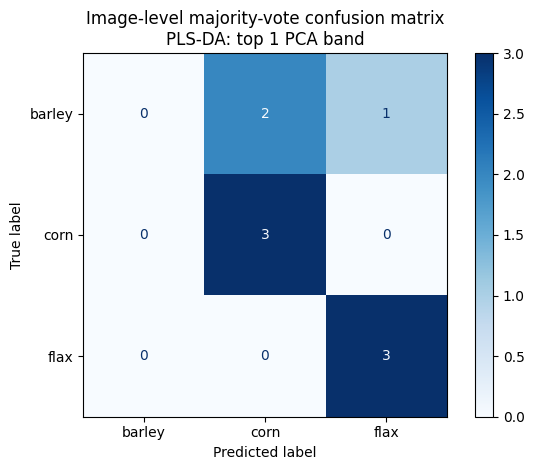

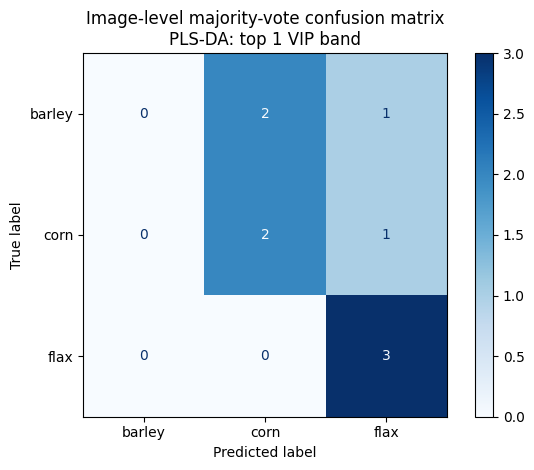

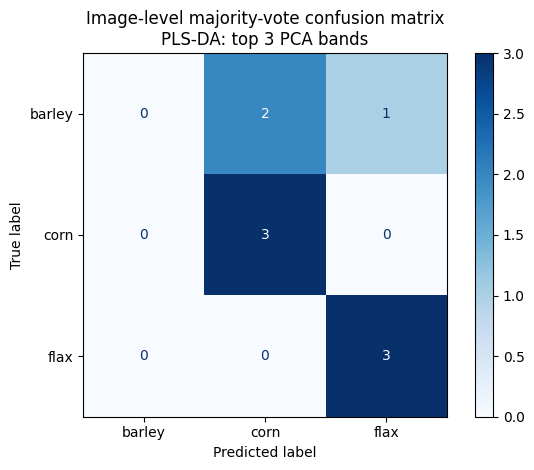

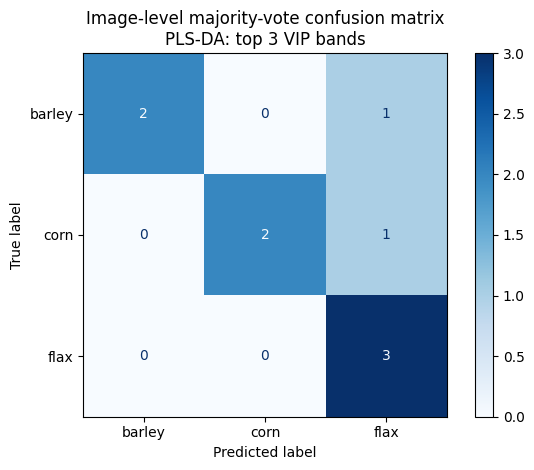

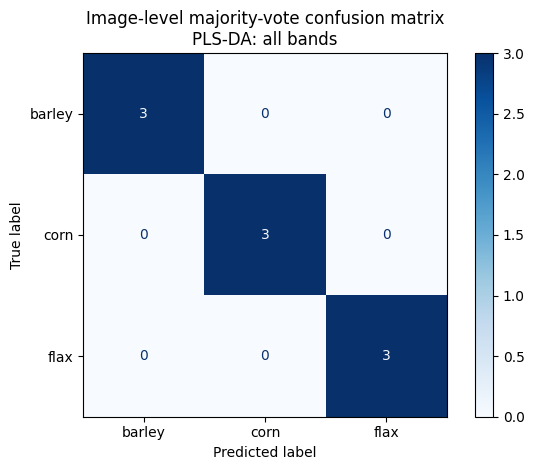

In [36]:
# --- Image-level majority-vote evaluation for selected 1/3-band models ---

from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

labels_to_evaluate = [
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
    "PLS-DA: all bands",
]

test_image_rows = files_split[files_split["split"] == "test"].copy()
test_image_rows = test_image_rows.sort_values(["variety", "size", "rep"]).reset_index(drop=True)

image_level_rows = []

for result_label in labels_to_evaluate:

    result = next(r for r in results_plsda_bands if r["label"] == result_label)

    model = result["model"]
    band_indices = result["band_indices"]
    train_mean = result["train_mean"]

    y_true_images = []
    y_pred_images = []

    for _, row in test_image_rows.iterrows():

        sample_name = row["sample_name"]
        true_label = row["variety"]
        size = row["size"]
        filepath = row["filepath_FX10"]

        hcube, wlens_img, darkref, whiteref = load_cube(filepath)
        hcube_c = hcube[75:1025, 100:875, :]

        mask = build_foreground_mask_auto(
            hcube_c,
            size=size,
            true_label=true_label
        )

        mask_binary = mask > 0
        y_coords, x_coords = np.nonzero(mask_binary)

        X_img = hcube_c[y_coords, x_coords, :]
        X_img_sub = X_img[:, band_indices]
        X_img_mc = X_img_sub - train_mean

        Y_scores = model.predict(X_img_mc)
        y_pred_pixels = lb.classes_[np.argmax(Y_scores, axis=1)]

        majority_pred = Counter(y_pred_pixels).most_common(1)[0][0]
        pixel_acc = np.mean(y_pred_pixels == true_label)

        y_true_images.append(true_label)
        y_pred_images.append(majority_pred)

        image_level_rows.append({
            "Model": result_label,
            "sample_name": sample_name,
            "true_label": true_label,
            "majority_prediction": majority_pred,
            "pixel_accuracy": pixel_acc,
            "image_correct": majority_pred == true_label,
        })

image_level_df = pd.DataFrame(image_level_rows)

display(image_level_df)

image_summary_df = (
    image_level_df
    .groupby("Model", as_index=False)
    .agg(
        image_accuracy=("image_correct", "mean"),
        mean_pixel_accuracy=("pixel_accuracy", "mean")
    )
)

display(image_summary_df)

for result_label in labels_to_evaluate:
    sub = image_level_df[image_level_df["Model"] == result_label]

    cm = confusion_matrix(
        sub["true_label"],
        sub["majority_prediction"],
        labels=lb.classes_
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=lb.classes_
    )

    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Image-level majority-vote confusion matrix\n{result_label}")
    plt.tight_layout()
    plt.show()

## Diagnostics
The following cells are mostly diagnostic measures to try and figure out why classification of barley images in particular are so bad when keeping a single, or just a few bands.

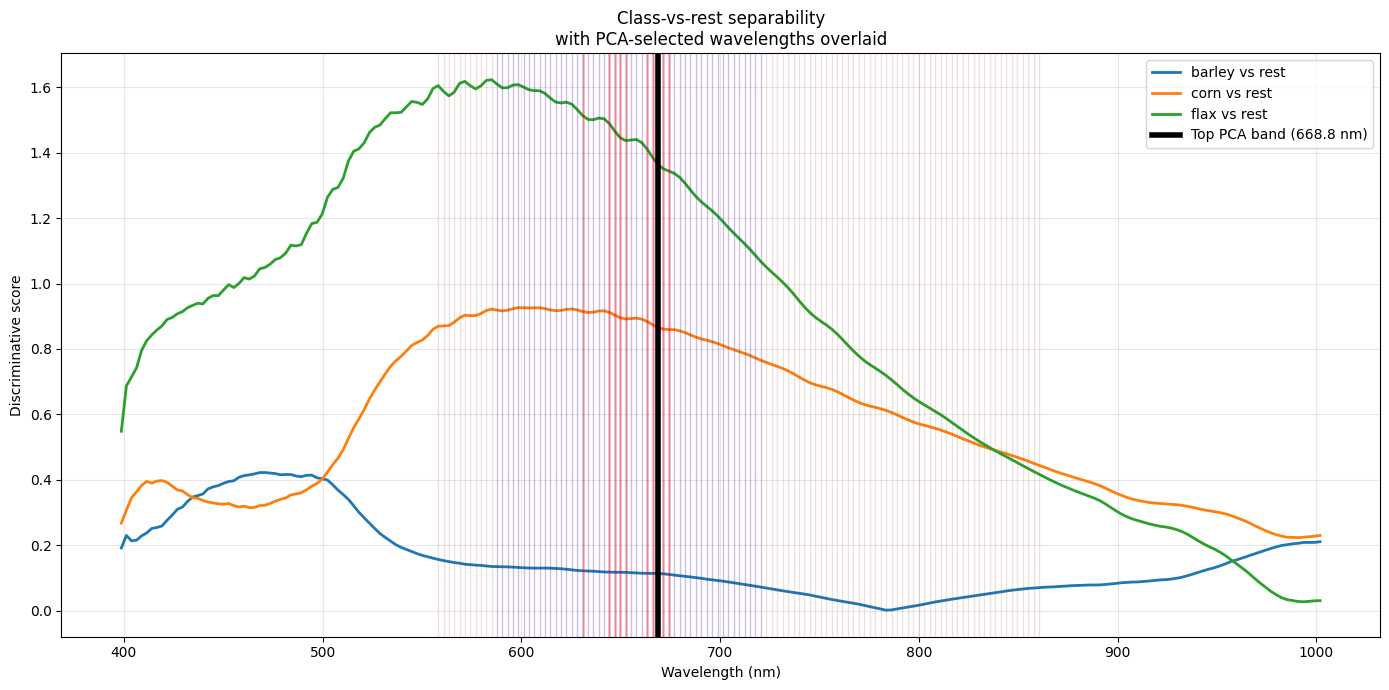

In [19]:
# --- Class vs Rest separability + PCA-selected bands ---

plt.figure(figsize=(14,7))

# Class-vs-rest curves
for target_class in lb.classes_:

    class_mean = X_train[y_train == target_class].mean(axis=0)
    rest_mean = X_train[y_train != target_class].mean(axis=0)

    class_std = X_train[y_train == target_class].std(axis=0)
    rest_std = X_train[y_train != target_class].std(axis=0)

    score = np.abs(class_mean - rest_mean) / (
        class_std + rest_std + 1e-8
    )

    plt.plot(
        wavelengths,
        score,
        linewidth=2,
        label=f"{target_class} vs rest"
    )

# PCA-selected wavelengths

top_half_wl = wavelengths[selected_band_indices_pca[:112]]
top_50_wl   = wavelengths[selected_band_indices_pca[:50]]
top_10_wl   = wavelengths[selected_band_indices_pca[:10]]
top_1_wl    = wavelengths[selected_band_indices_pca[:1]]

# Top half bands
for wl in top_half_wl:
    plt.axvline(
        wl,
        color="brown",
        alpha=0.15,
        linewidth=1
    )

# Top 50 bands
for wl in top_50_wl:
    plt.axvline(
        wl,
        color="blue",
        alpha=0.15,
        linewidth=1
    )

# Top 10 bands
for wl in top_10_wl:
    plt.axvline(
        wl,
        color="red",
        alpha=0.25,
        linewidth=2
    )

# Top 1 band
plt.axvline(
    top_1_wl[0],
    color="black",
    linewidth=4,
    label=f"Top PCA band ({top_1_wl[0]:.1f} nm)"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Discriminative score")
plt.title(
    "Class-vs-rest separability\n"
    "with PCA-selected wavelengths overlaid"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

This ^ cell calculates:

(difference between mean reflectance of a class and mean reflectance of other 2 classes combined) / sum of all within-group variabilities


,Model,Number of bands,Class,Correct,Total,Class accuracy
48,PLS-DA: top 1 PCA band,1,barley,0,3000,0.000000
51,PLS-DA: top 1 VIP band,1,barley,0,3000,0.000000
49,PLS-DA: top 1 PCA band,1,corn,2536,3000,0.845333
52,PLS-DA: top 1 VIP band,1,corn,1801,3000,0.600333
50,PLS-DA: top 1 PCA band,1,flax,2969,3000,0.989667
53,PLS-DA: top 1 VIP band,1,flax,2547,3000,0.849000
42,PLS-DA: top 3 PCA bands,3,barley,160,3000,0.053333
45,PLS-DA: top 3 VIP bands,3,barley,1467,3000,0.489000
43,PLS-DA: top 3 PCA bands,3,corn,2652,3000,0.884000
46,PLS-DA: top 3 VIP bands,3,corn,1139,3000,0.379667


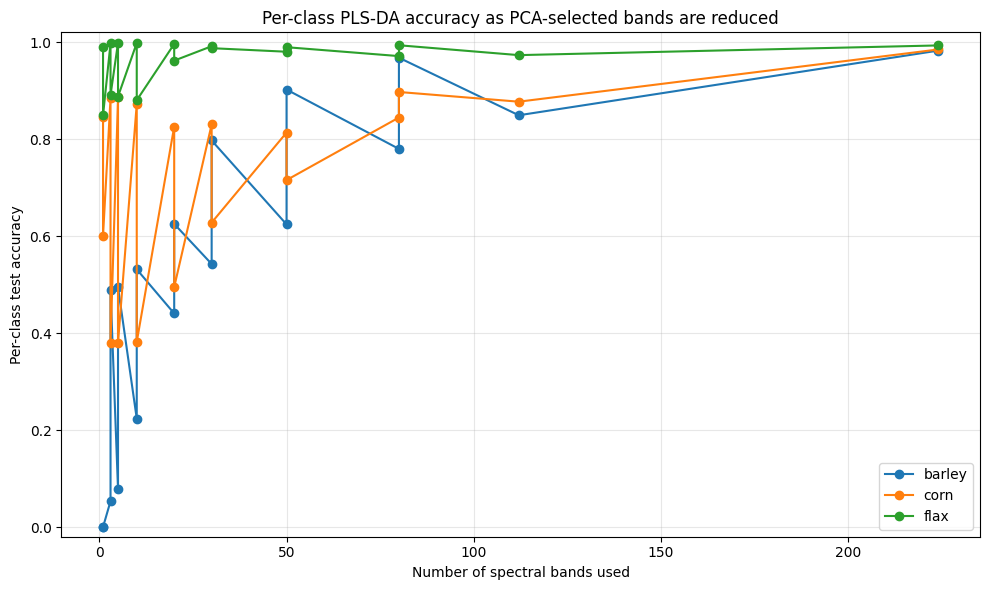

In [20]:
# --- Barley diagnostic 1: Per-class accuracy across reduced band sets ---

per_class_rows = []

for result in results_plsda_bands:
    cm = result["confusion_matrix"]
    
    for i, cls in enumerate(lb.classes_):
        total = cm[i, :].sum()
        correct = cm[i, i]
        class_acc = correct / total if total > 0 else np.nan
        
        per_class_rows.append({
            "Model": result["label"],
            "Number of bands": result["n_bands"],
            "Class": cls,
            "Correct": correct,
            "Total": total,
            "Class accuracy": class_acc
        })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df = per_class_df.sort_values(["Number of bands", "Class"])

display(per_class_df)

plt.figure(figsize=(10, 6))

for cls in lb.classes_:
    subset = per_class_df[per_class_df["Class"] == cls]
    plt.plot(
        subset["Number of bands"],
        subset["Class accuracy"],
        marker="o",
        label=cls
    )

plt.xlabel("Number of spectral bands used")
plt.ylabel("Per-class test accuracy")
plt.title("Per-class PLS-DA accuracy as PCA-selected bands are reduced")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

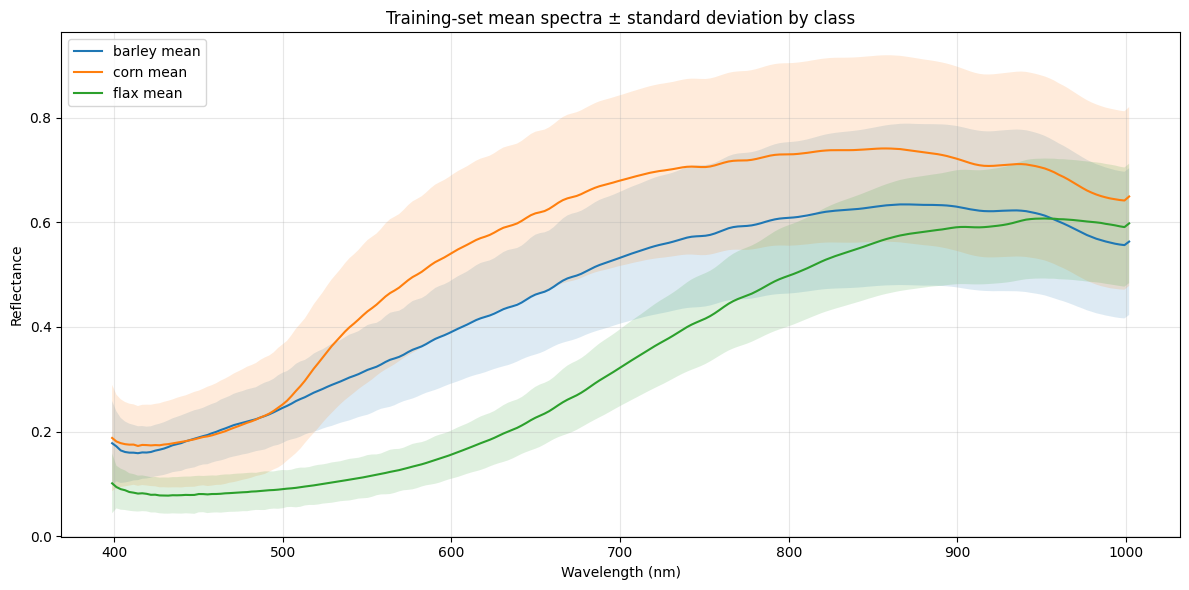

In [21]:
# --- Barley diagnostic 2: Mean spectra ± standard deviation per class ---

classes = lb.classes_

plt.figure(figsize=(12, 6))

for cls in classes:
    X_cls = X_train[y_train == cls]

    mean_spectrum = X_cls.mean(axis=0)
    std_spectrum = X_cls.std(axis=0)

    plt.plot(wavelengths, mean_spectrum, label=f"{cls} mean")
    plt.fill_between(
        wavelengths,
        mean_spectrum - std_spectrum,
        mean_spectrum + std_spectrum,
        alpha=0.15
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Training-set mean spectra ± standard deviation by class")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

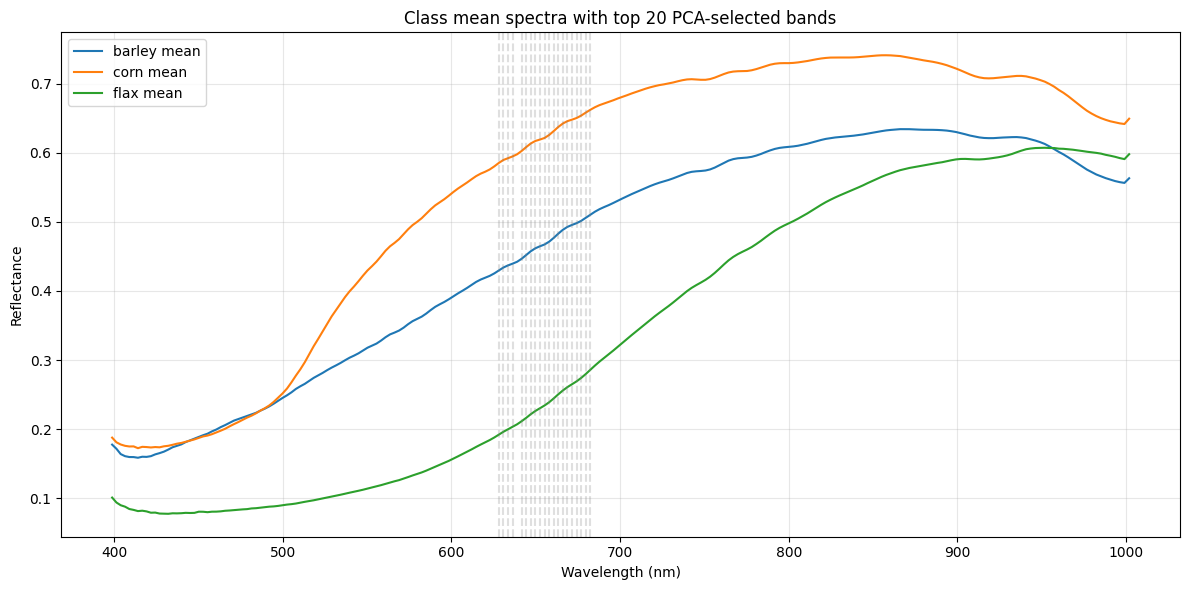

Top PCA-selected wavelengths:
[668.8 666.  649.8 647.1 671.5 663.3 652.5 674.2 644.4 630.8 633.5 660.6
 655.2 676.9 636.2 657.9 679.6 628.1 641.6 682.4]


In [22]:
# --- Barley diagnostic 3: Mean spectra with selected PCA bands marked ---

N_MARKED_BANDS = 20
bands_to_mark = selected_band_indices_pca[:N_MARKED_BANDS]

plt.figure(figsize=(12, 6))

for cls in classes:
    X_cls = X_train[y_train == cls]
    plt.plot(
        wavelengths,
        X_cls.mean(axis=0),
        label=f"{cls} mean"
    )

for b in bands_to_mark:
    plt.axvline(
        wavelengths[b],
        color="gray",
        alpha=0.25,
        linestyle="--"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title(f"Class mean spectra with top {N_MARKED_BANDS} PCA-selected bands")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top PCA-selected wavelengths:")
print(np.round(wavelengths[bands_to_mark], 1))

,Band case,Number of bands,Pair,Euclidean distance
0,All bands,224,barley vs corn,1.635325
1,All bands,224,barley vs flax,2.280632
2,All bands,224,corn vs flax,3.773220
3,Top 112 PCA bands,112,barley vs corn,1.457132
4,Top 112 PCA bands,112,barley vs flax,1.978360
5,Top 112 PCA bands,112,corn vs flax,3.415381
6,Top 80 PCA bands,80,barley vs corn,1.295647
7,Top 80 PCA bands,80,barley vs flax,1.882419
8,Top 80 PCA bands,80,corn vs flax,3.173874
9,Top 50 PCA bands,50,barley vs corn,1.069823


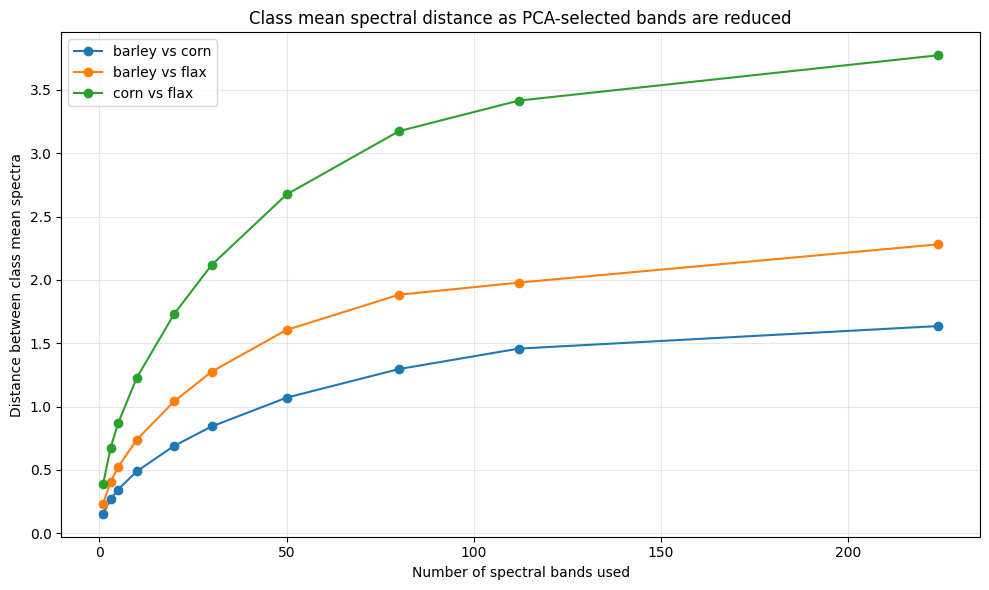

In [23]:
# --- Barley diagnostic 4: Distance between class mean spectra ---

from scipy.spatial.distance import euclidean
from itertools import combinations

DISTANCE_BAND_CASES = [
    ("All bands", np.arange(X_train.shape[1])),
    ("Top 112 PCA bands", selected_band_indices_pca[:112]),
    ("Top 80 PCA bands", selected_band_indices_pca[:80]),
    ("Top 50 PCA bands", selected_band_indices_pca[:50]),
    ("Top 30 PCA bands", selected_band_indices_pca[:30]),
    ("Top 20 PCA bands", selected_band_indices_pca[:20]),
    ("Top 10 PCA bands", selected_band_indices_pca[:10]),
    ("Top 5 PCA bands", selected_band_indices_pca[:5]),
    ("Top 3 PCA bands", selected_band_indices_pca[:3]),
    ("Top 1 PCA band", selected_band_indices_pca[:1]),
]

distance_rows = []

for band_label, band_indices in DISTANCE_BAND_CASES:

    class_means = {}

    for cls in classes:
        class_means[cls] = X_train[y_train == cls][:, band_indices].mean(axis=0)

    for c1, c2 in combinations(classes, 2):
        dist = euclidean(class_means[c1], class_means[c2])

        distance_rows.append({
            "Band case": band_label,
            "Number of bands": len(band_indices),
            "Pair": f"{c1} vs {c2}",
            "Euclidean distance": dist
        })

distance_df = pd.DataFrame(distance_rows)
display(distance_df)

plt.figure(figsize=(10, 6))

for pair in distance_df["Pair"].unique():
    subset = distance_df[distance_df["Pair"] == pair].sort_values("Number of bands")
    plt.plot(
        subset["Number of bands"],
        subset["Euclidean distance"],
        marker="o",
        label=pair
    )

plt.xlabel("Number of spectral bands used")
plt.ylabel("Distance between class mean spectra")
plt.title("Class mean spectral distance as PCA-selected bands are reduced")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,Band case,Number of bands,Class,Mean distance to class mean,Std distance to class mean
0,All bands,224,barley,1.455739,1.039793
1,All bands,224,corn,1.925938,1.233919
2,All bands,224,flax,0.954212,0.682685
3,Top 112 PCA bands,112,barley,1.064790,0.805661
4,Top 112 PCA bands,112,corn,1.403720,0.999904
5,Top 112 PCA bands,112,flax,0.648748,0.489572
6,Top 80 PCA bands,80,barley,0.839031,0.644192
7,Top 80 PCA bands,80,corn,1.155542,0.820316
8,Top 80 PCA bands,80,flax,0.476075,0.370787
9,Top 50 PCA bands,50,barley,0.638289,0.498461


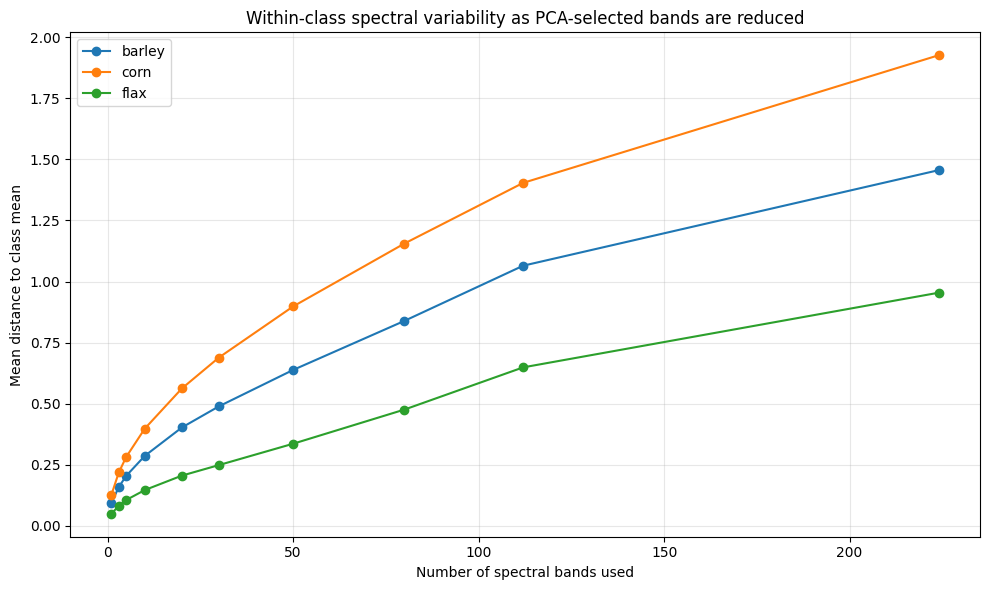

In [24]:
# --- Barley diagnostic 5: Within-class spectral variability ---

variability_rows = []

for band_label, band_indices in DISTANCE_BAND_CASES:

    for cls in classes:
        X_cls = X_train[y_train == cls][:, band_indices]

        class_mean = X_cls.mean(axis=0)

        distances_to_mean = np.linalg.norm(
            X_cls - class_mean,
            axis=1
        )

        variability_rows.append({
            "Band case": band_label,
            "Number of bands": len(band_indices),
            "Class": cls,
            "Mean distance to class mean": distances_to_mean.mean(),
            "Std distance to class mean": distances_to_mean.std()
        })

variability_df = pd.DataFrame(variability_rows)
display(variability_df)

plt.figure(figsize=(10, 6))

for cls in classes:
    subset = variability_df[variability_df["Class"] == cls].sort_values("Number of bands")
    plt.plot(
        subset["Number of bands"],
        subset["Mean distance to class mean"],
        marker="o",
        label=cls
    )

plt.xlabel("Number of spectral bands used")
plt.ylabel("Mean distance to class mean")
plt.title("Within-class spectral variability as PCA-selected bands are reduced")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# --- Barley diagnostic 6: summary focused on barley ---

barley_summary = per_class_df[
    per_class_df["Class"] == "barley"
].copy()

barley_summary = barley_summary.merge(
    metrics_df[["Model", "Accuracy"]],
    on="Model",
    how="left"
)

barley_summary = barley_summary.rename(columns={
    "Class accuracy": "Barley accuracy",
    "Accuracy": "Overall accuracy",
    "F1-score": "Overall macro F1"
})

display(
    barley_summary[
        [
            "Model",
            "Number of bands",
            "Barley accuracy",
            "Overall accuracy",
            "Correct",
            "Total"
        ]
    ].sort_values("Number of bands")
)

,Model,Number of bands,Barley accuracy,Overall accuracy,Correct,Total
0,PLS-DA: top 1 PCA band,1,0.000000,0.611667,0,3000
1,PLS-DA: top 1 VIP band,1,0.000000,0.483111,0,3000
2,PLS-DA: top 3 PCA bands,3,0.053333,0.644889,160,3000
3,PLS-DA: top 3 VIP bands,3,0.489000,0.586444,1467,3000
4,PLS-DA: top 5 PCA bands,5,0.078000,0.654111,234,3000
5,PLS-DA: top 5 VIP bands,5,0.494333,0.587222,1483,3000
6,PLS-DA: top 10 PCA bands,10,0.223667,0.697889,671,3000
7,PLS-DA: top 10 VIP bands,10,0.531333,0.597667,1594,3000
8,PLS-DA: top 20 PCA bands,20,0.440333,0.754000,1321,3000
9,PLS-DA: top 20 VIP bands,20,0.625000,0.693778,1875,3000


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.000000
1,barley_l4,barley,l,interior,347703,0.000000
2,barley_m4,barley,m,edge,170370,0.000000
3,barley_m4,barley,m,interior,471231,0.000000
4,barley_s4,barley,s,edge,137817,0.000000
5,barley_s4,barley,s,interior,298038,0.000000
6,corn_l4,corn,l,edge,135633,0.966439
7,corn_l4,corn,l,interior,394252,0.999977
8,corn_m4,corn,m,edge,94657,0.245645
9,corn_m4,corn,m,interior,354325,0.983151


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.0
1,barley_l4,barley,l,interior,347703,0.0
2,barley_m4,barley,m,edge,170370,0.0
3,barley_m4,barley,m,interior,471231,0.0
4,barley_s4,barley,s,edge,137817,0.0
5,barley_s4,barley,s,interior,298038,0.0


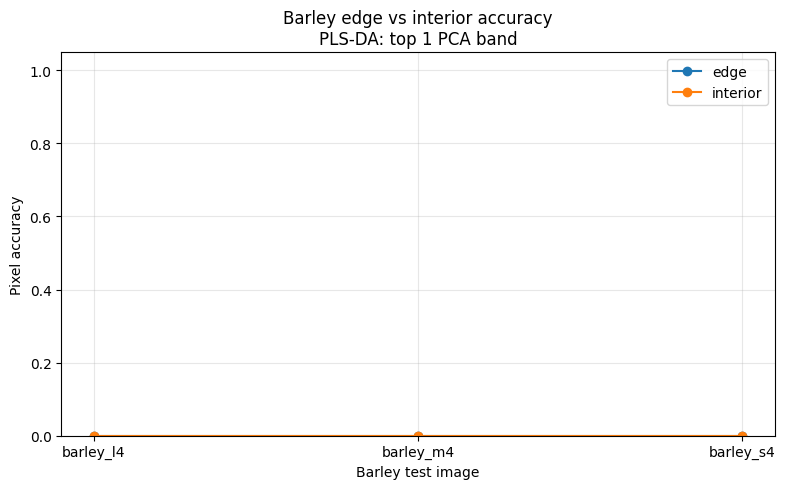

,true_label,region,mean_accuracy,std_accuracy,total_pixels
0,barley,edge,0.000000,0.000000,519742
1,barley,interior,0.000000,0.000000,1116972
2,corn,edge,0.422292,0.480809,278380
3,corn,interior,0.981286,0.019690,913305
4,flax,edge,1.000000,0.000000,454863
5,flax,interior,0.988836,0.001420,1349099


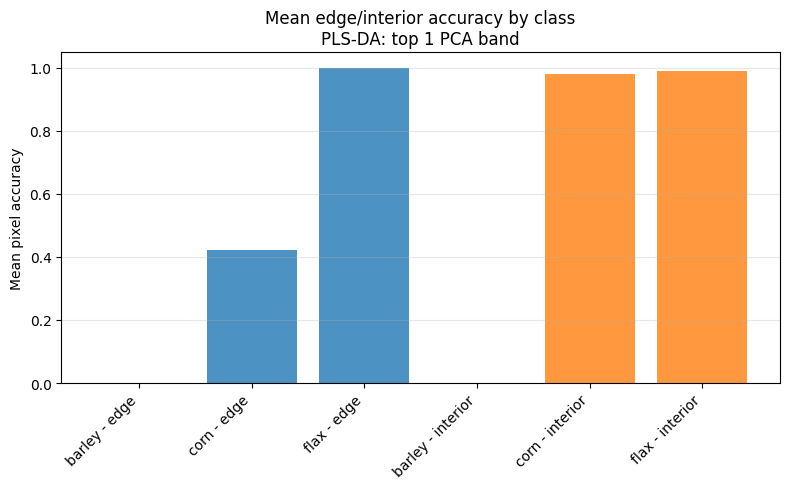

,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.000000
1,barley_m4,barley,m,641601,736250,0.871444,0.000000
2,barley_s4,barley,s,435855,736250,0.591993,0.000000
3,corn_l4,corn,l,529885,736250,0.719708,0.991392
4,corn_m4,corn,m,448982,736250,0.609823,0.827666
5,corn_s4,corn,s,212818,736250,0.289057,0.756017
6,flax_l4,flax,l,564336,736250,0.766501,0.992251
7,flax_m4,flax,m,584102,736250,0.793347,0.991714
8,flax_s4,flax,s,655524,736250,0.890355,0.991544


,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.0
1,barley_m4,barley,m,641601,736250,0.871444,0.0
2,barley_s4,barley,s,435855,736250,0.591993,0.0


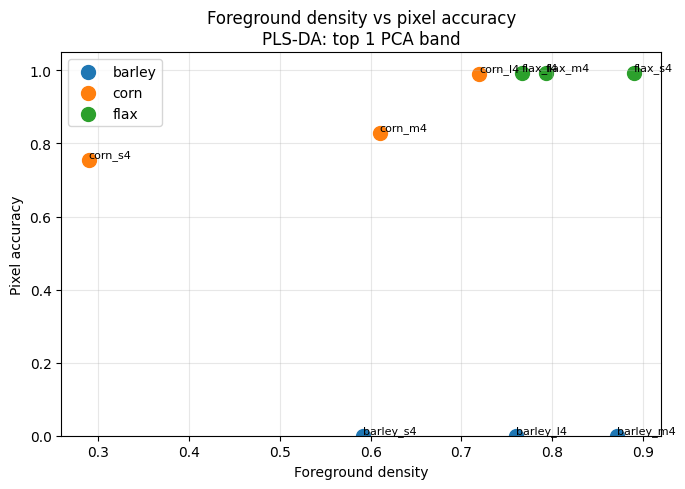

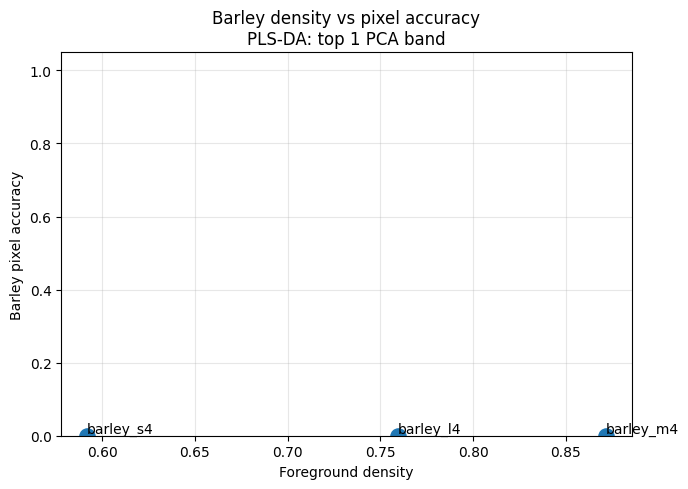

Correlation between barley foreground density and pixel accuracy:
nan


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.000000
1,barley_l4,barley,l,interior,347703,0.000000
2,barley_m4,barley,m,edge,170370,0.000000
3,barley_m4,barley,m,interior,471231,0.000000
4,barley_s4,barley,s,edge,137817,0.000000
5,barley_s4,barley,s,interior,298038,0.000000
6,corn_l4,corn,l,edge,135633,0.959803
7,corn_l4,corn,l,interior,394252,0.973058
8,corn_m4,corn,m,edge,94657,0.528371
9,corn_m4,corn,m,interior,354325,0.635676


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.0
1,barley_l4,barley,l,interior,347703,0.0
2,barley_m4,barley,m,edge,170370,0.0
3,barley_m4,barley,m,interior,471231,0.0
4,barley_s4,barley,s,edge,137817,0.0
5,barley_s4,barley,s,interior,298038,0.0


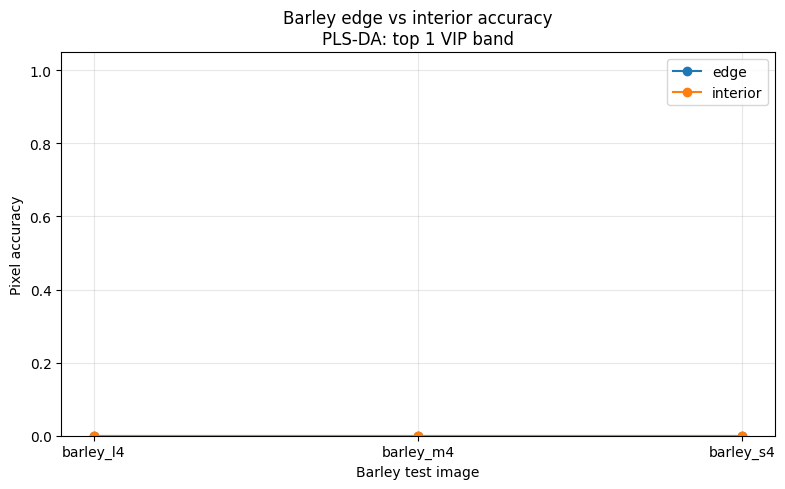

,true_label,region,mean_accuracy,std_accuracy,total_pixels
0,barley,edge,0.000000,0.000000,519742
1,barley,interior,0.000000,0.000000,1116972
2,corn,edge,0.537543,0.417750,278380
3,corn,interior,0.605257,0.383915,913305
4,flax,edge,0.877918,0.053771,454863
5,flax,interior,0.831355,0.064919,1349099


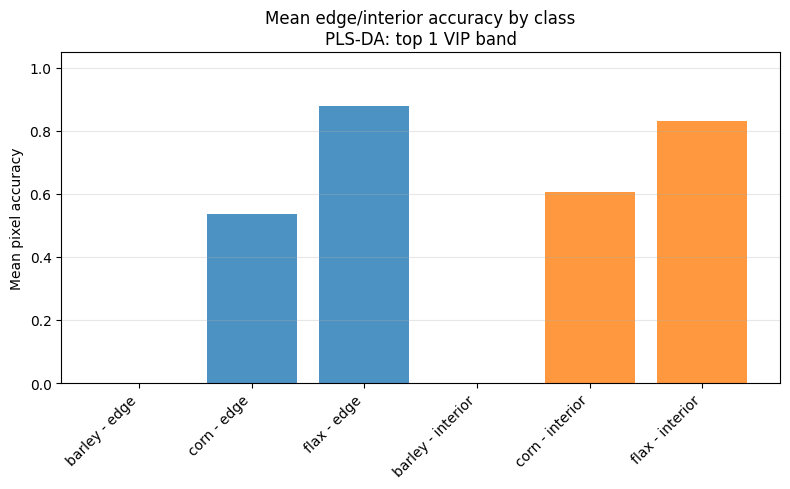

,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.000000
1,barley_m4,barley,m,641601,736250,0.871444,0.000000
2,barley_s4,barley,s,435855,736250,0.591993,0.000000
3,corn_l4,corn,l,529885,736250,0.719708,0.969665
4,corn_m4,corn,m,448982,736250,0.609823,0.613054
5,corn_s4,corn,s,212818,736250,0.289057,0.188377
6,flax_l4,flax,l,564336,736250,0.766501,0.797450
7,flax_m4,flax,m,584102,736250,0.793347,0.827546
8,flax_s4,flax,s,655524,736250,0.890355,0.908008


,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.0
1,barley_m4,barley,m,641601,736250,0.871444,0.0
2,barley_s4,barley,s,435855,736250,0.591993,0.0


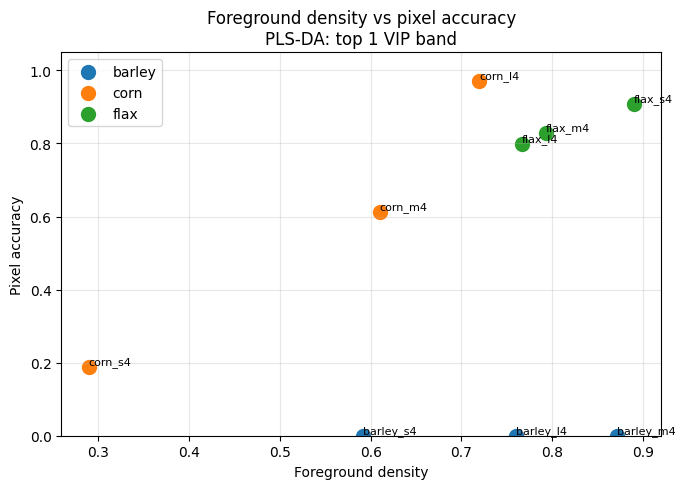

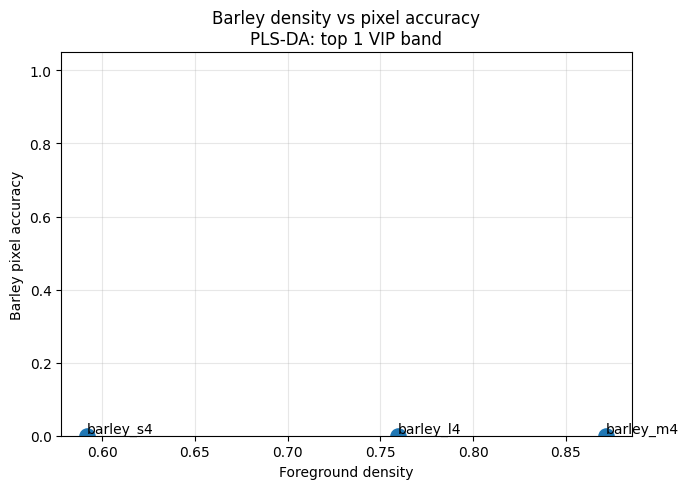

Correlation between barley foreground density and pixel accuracy:
nan


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.039186
1,barley_l4,barley,l,interior,347703,0.039545
2,barley_m4,barley,m,edge,170370,0.079351
3,barley_m4,barley,m,interior,471231,0.055262
4,barley_s4,barley,s,edge,137817,0.064477
5,barley_s4,barley,s,interior,298038,0.084211
6,corn_l4,corn,l,edge,135633,0.872236
7,corn_l4,corn,l,interior,394252,0.989720
8,corn_m4,corn,m,edge,94657,0.646196
9,corn_m4,corn,m,interior,354325,0.975788


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.039186
1,barley_l4,barley,l,interior,347703,0.039545
2,barley_m4,barley,m,edge,170370,0.079351
3,barley_m4,barley,m,interior,471231,0.055262
4,barley_s4,barley,s,edge,137817,0.064477
5,barley_s4,barley,s,interior,298038,0.084211


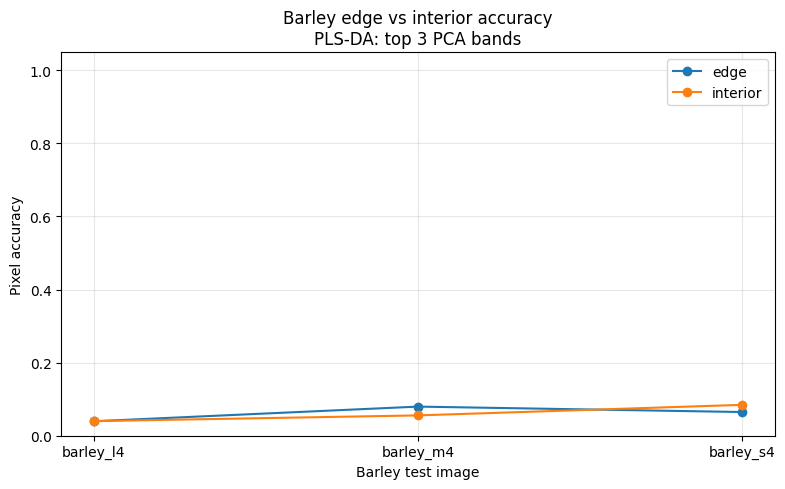

,true_label,region,mean_accuracy,std_accuracy,total_pixels
0,barley,edge,0.061005,0.020306,519742
1,barley,interior,0.059673,0.022657,1116972
2,corn,edge,0.678203,0.180174,278380
3,corn,interior,0.977828,0.011014,913305
4,flax,edge,0.999765,0.000212,454863
5,flax,interior,0.997398,0.000563,1349099


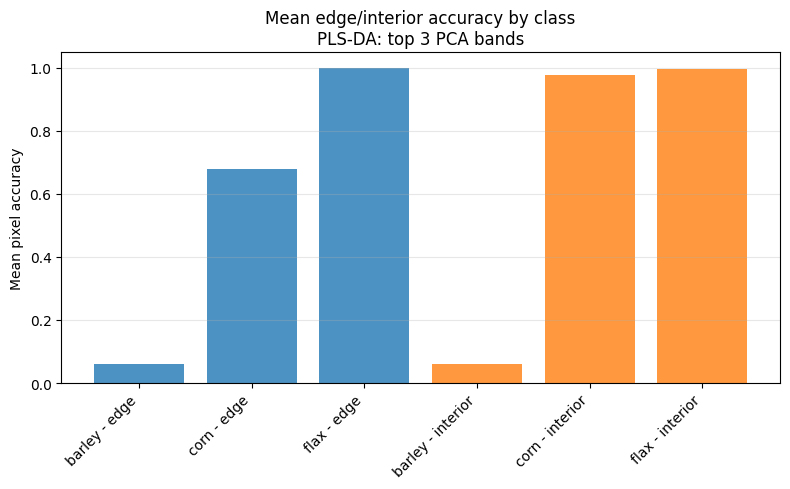

,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.039409
1,barley_m4,barley,m,641601,736250,0.871444,0.061658
2,barley_s4,barley,s,435855,736250,0.591993,0.077971
3,corn_l4,corn,l,529885,736250,0.719708,0.959648
4,corn_m4,corn,m,448982,736250,0.609823,0.906301
5,corn_s4,corn,s,212818,736250,0.289057,0.865885
6,flax_l4,flax,l,564336,736250,0.766501,0.997994
7,flax_m4,flax,m,584102,736250,0.793347,0.997887
8,flax_s4,flax,s,655524,736250,0.890355,0.998261


,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.039409
1,barley_m4,barley,m,641601,736250,0.871444,0.061658
2,barley_s4,barley,s,435855,736250,0.591993,0.077971


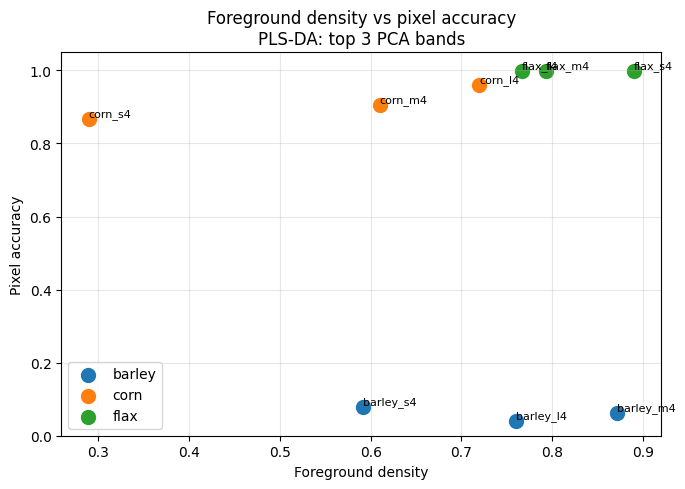

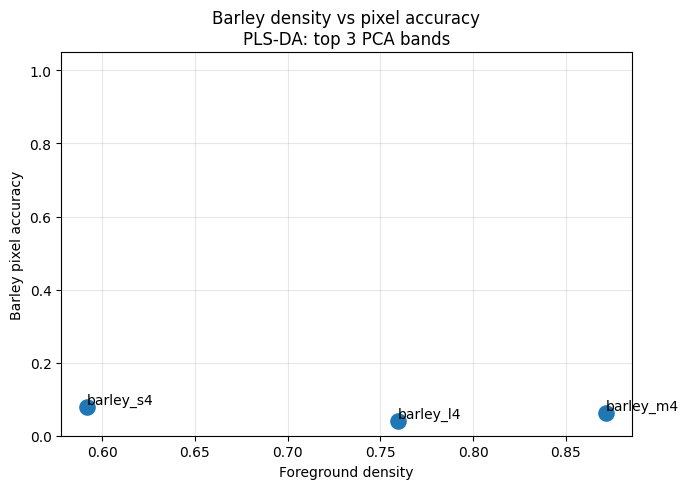

Correlation between barley foreground density and pixel accuracy:
-0.522403018838016


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.736196
1,barley_l4,barley,l,interior,347703,0.173479
2,barley_m4,barley,m,edge,170370,0.934572
3,barley_m4,barley,m,interior,471231,0.484531
4,barley_s4,barley,s,edge,137817,0.741469
5,barley_s4,barley,s,interior,298038,0.279119
6,corn_l4,corn,l,edge,135633,0.351161
7,corn_l4,corn,l,interior,394252,0.910841
8,corn_m4,corn,m,edge,94657,0.018604
9,corn_m4,corn,m,interior,354325,0.508861


,sample_name,true_label,size,region,n_pixels,accuracy
0,barley_l4,barley,l,edge,211555,0.736196
1,barley_l4,barley,l,interior,347703,0.173479
2,barley_m4,barley,m,edge,170370,0.934572
3,barley_m4,barley,m,interior,471231,0.484531
4,barley_s4,barley,s,edge,137817,0.741469
5,barley_s4,barley,s,interior,298038,0.279119


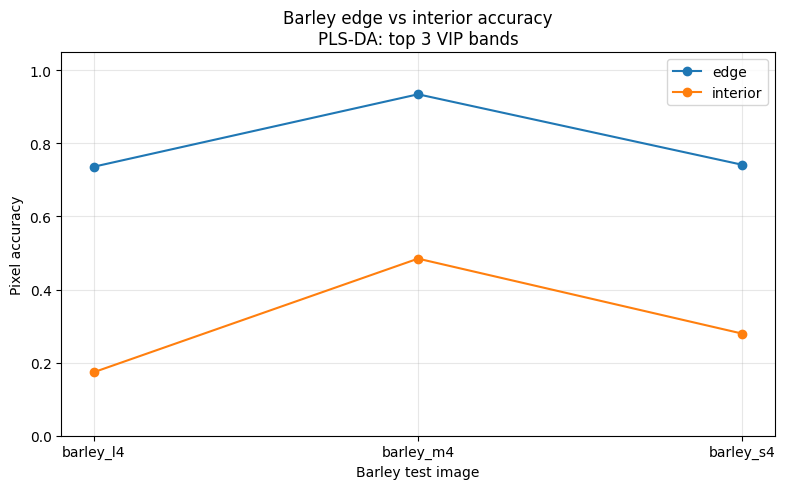

,true_label,region,mean_accuracy,std_accuracy,total_pixels
0,barley,edge,0.804079,0.113041,519742
1,barley,interior,0.312376,0.158171,1116972
2,corn,edge,0.123297,0.197552,278380
3,corn,interior,0.514413,0.393682,913305
4,flax,edge,0.794838,0.222583,454863
5,flax,interior,0.904033,0.010672,1349099


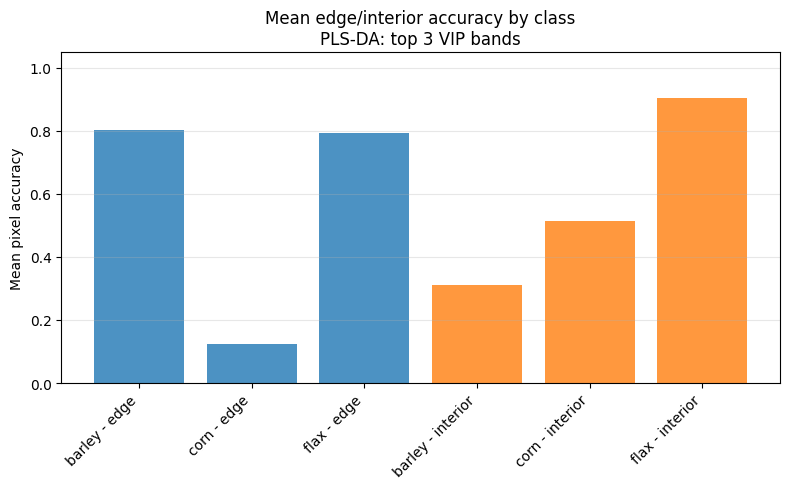

,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.386342
1,barley_m4,barley,m,641601,736250,0.871444,0.604034
2,barley_s4,barley,s,435855,736250,0.591993,0.425313
3,corn_l4,corn,l,529885,736250,0.719708,0.767582
4,corn_m4,corn,m,448982,736250,0.609823,0.405502
5,corn_s4,corn,s,212818,736250,0.289057,0.095650
6,flax_l4,flax,l,564336,736250,0.766501,0.912469
7,flax_m4,flax,m,584102,736250,0.793347,0.913298
8,flax_s4,flax,s,655524,736250,0.890355,0.855183


,sample_name,true_label,size,foreground_pixels,image_pixels,foreground_density,pixel_accuracy
0,barley_l4,barley,l,559258,736250,0.759603,0.386342
1,barley_m4,barley,m,641601,736250,0.871444,0.604034
2,barley_s4,barley,s,435855,736250,0.591993,0.425313


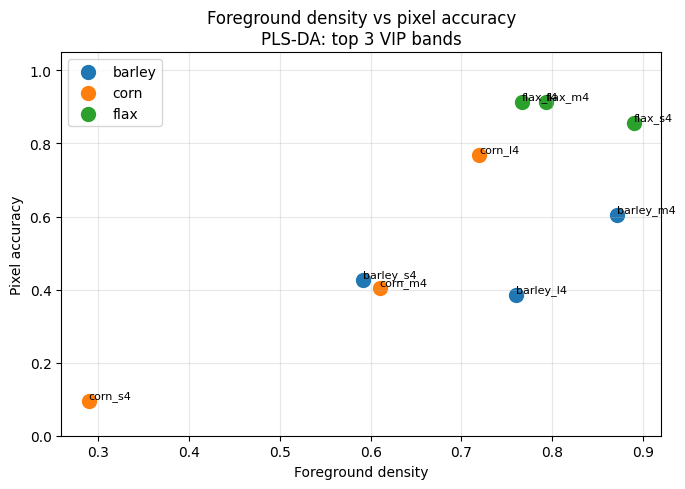

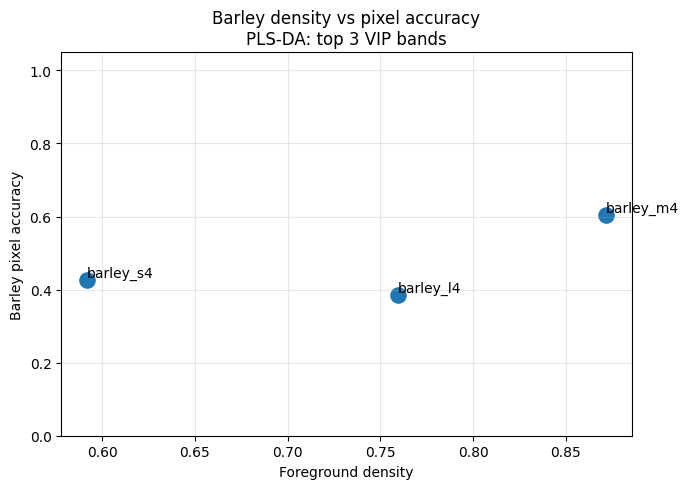

Correlation between barley foreground density and pixel accuracy:
0.691688176794755


In [ ]:
# --- Barley diagnostic: edge vs interior pixel accuracy ---

from skimage.morphology import binary_erosion, disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

labels_to_plot = [
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]

for label in labels_to_plot:
    result_to_diagnose = next(
        r for r in results_plsda_bands
        if r["label"] == label
    )

    model = result_to_diagnose["model"]
    band_indices = result_to_diagnose["band_indices"]
    train_mean = result_to_diagnose["train_mean"]

    test_image_rows = files_split[files_split["split"] == "test"].copy()
    test_image_rows = test_image_rows.sort_values(["variety", "size", "rep"])

    edge_rows = []

    for _, row in test_image_rows.iterrows():

        sample_name = row["sample_name"]
        var = row["variety"]
        size = row["size"]
        filepath = row["filepath_FX10"]

        hcube, wlens_img, darkref, whiteref = load_cube(filepath)

        # Same crop used in your spectral notebook
        hcube_c = hcube[75:1025, 100:875, :] # height, width, spectral crop
        wlens_c = wlens[:]
        
        mask = build_foreground_mask_auto(
            hcube_c,
            size=size,
            true_label=var
        )

        mask_binary = mask > 0

        # Define edge and interior pixels
        interior_mask = binary_erosion(mask_binary, disk(3))
        edge_mask = mask_binary & ~interior_mask

        y_coords, x_coords = np.nonzero(mask_binary)

        X_img = hcube_c[y_coords, x_coords, :]
        X_img_sub = X_img[:, band_indices]
        X_img_mc = X_img_sub - train_mean

        Y_scores = model.predict(X_img_mc)
        y_pred_pixels = lb.classes_[np.argmax(Y_scores, axis=1)]

        correct_pixels = y_pred_pixels == var

        region_labels = np.full(mask_binary.shape, "background", dtype=object)
        region_labels[edge_mask] = "edge"
        region_labels[interior_mask] = "interior"

        pixel_regions = region_labels[y_coords, x_coords]

        for region in ["edge", "interior"]:
            region_mask = pixel_regions == region

            if region_mask.sum() == 0:
                region_acc = np.nan
            else:
                region_acc = correct_pixels[region_mask].mean()

            edge_rows.append({
                "sample_name": sample_name,
                "true_label": var,
                "size": row["size"],
                "region": region,
                "n_pixels": region_mask.sum(),
                "accuracy": region_acc
            })

    edge_accuracy_df = pd.DataFrame(edge_rows)

    display(edge_accuracy_df)

    barley_edge_df = edge_accuracy_df[
        edge_accuracy_df["true_label"] == "barley"
    ].copy()

    display(barley_edge_df)

    plt.figure(figsize=(8, 5))

    for region in ["edge", "interior"]:
        subset = barley_edge_df[barley_edge_df["region"] == region]
        plt.plot(
            subset["sample_name"],
            subset["accuracy"],
            marker="o",
            label=region
        )

    plt.xlabel("Barley test image")
    plt.ylabel("Pixel accuracy")
    plt.title(f"Barley edge vs interior accuracy\n{label}")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Edge vs interior summary by class ---

    edge_summary_df = (
        edge_accuracy_df
        .groupby(["true_label", "region"], as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            total_pixels=("n_pixels", "sum")
        )
    )

    display(edge_summary_df)

    plt.figure(figsize=(8, 5))

    for region in ["edge", "interior"]:
        subset = edge_summary_df[edge_summary_df["region"] == region]
        plt.bar(
            subset["true_label"] + " - " + region,
            subset["mean_accuracy"],
            alpha=0.8
        )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean pixel accuracy")
    plt.title(f"Mean edge/interior accuracy by class\n{label}")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
